# Iterative Methods

Dalam kuliah ini kita akan membahas beberapa metode klasik dan lebih modern untuk menyelesaikan sistem linear sparse seperti yang kita temukan dari pertimbangan masalah nilai batas (boundary value problems).

## Cara Menyelesaikan $Au = f$

Kita telah mengusulkan penyelesaian sistem linear $Au = f$ yang sebelumnya diimplementasikan secara naif dengan perintah  
`numpy.linalg.solve`,  
namun mengingat struktur khusus matriks $A$ di sini, mungkin kita dapat melakukannya dengan lebih baik.

## Metode Langsung (Gaussian Elimination)

Kita bisa menggunakan Gaussian elimination (atau beberapa faktorisasi) untuk menyelesaikan sistem ini, yang menghasilkan solusi dalam jumlah langkah yang terbatas. 

Namun, untuk sistem yang besar dan sparse, metode penyelesai langsung ini umumnya jauh lebih mahal dibandingkan dengan metode iteratif. Seperti yang telah dibahas pada masalah eigen, metode iteratif dimulai dengan tebakan awal (initial guess) dan berusaha memperbaiki tebakan tersebut secara bertahap.

#### Beban Komputasi

Sekarang pertimbangkan penggunaan Gaussian elimination pada matriks di atas. Untuk ukuran yang lebih realistis, mari kita ambil masalah 3D dan diskretisasi setiap dimensi dengan $N = 100$, sehingga menghasilkan $m = 100 \times 100 \times 100 = 10^6$ variabel tidak diketahui.

**Gaussian Elimination** — $\mathcal{O}(m^3)$ operasi untuk menyelesaikan,  
$(10^6)^3 = 10^{18}$ operasi.

Misalkan Anda memiliki mesin yang dapat melakukan 100 gigaflops (100 miliar operasi floating point per detik):

$$
    \frac{10^{18}~ [\text{flop}]}{10^{11}~ [\text{flop / s}]} = 10^7~\text{s} \approx 115~\text{hari}.
$$

#### Beban Memori

Bagaimana dengan memori?

Kita membutuhkan $m^2$ untuk menyimpan seluruh array. Dalam format *double precision floating point*, kita memerlukan 8 byte untuk setiap elemen sehingga diperoleh:

$$
(10^6)^2 ~[\text{elemen}] \times 8 ~[\text{byte / elemen}] = 8 \times 10^{12} ~[\text{byte}] = 8 ~[\text{terabyte}]
$$

Situasinya sebenarnya tidak seburuk yang kita bayangkan, selama kita memanfaatkan sifat *sparse* (jarang) dari matriks. Bahkan, untuk masalah satu dimensi, metode langsung (*metode langsung*) dapat direduksi menjadi $\mathcal{O}(N)$ dalam kasus sistem tridiagonal. Namun, untuk masalah berdimensi lebih tinggi, masalahnya tidak sebaik itu kecuali terdapat struktur tambahan yang dapat dimanfaatkan. Contoh dari jenis solver ini adalah metode Fourier cepat, seperti *fast Poisson solvers*

## Jacobi dan Gauss-Seidel Metode Jacobi dan
Gauss-Seidel merupakan pendekatan sederhana untuk memperkenalkan cara iteratif dalam menyelesaikan masalah $Ax = b$ ketika matriks $A$ bersifat *sparse* (jarang). memperhitungkan kembali masalah Poisson $u_{xx} = f(x)$ dan pendekatan beda hingga (*finite differential*) pada titik $x_i$: $$ \frac{U_{i-1} - 2 U_i + U_{i+1}}{\Delta x^2} = f(x_i). $$ Jika kita menyusun ulang persamaan ini untuk mencari $U_i$, diperoleh: $$ U_i = \frac{1}{2} (U_{i+1} + U_{i-1}) - f(x_i) \frac{\Delta x^2}{2}. $$ Pada metode langsung (*direct method*), kita akan mencari nilai $U_i$, $U_{i+1}$, dan $U_{i-1}$ secara bersamaan. Namun, pada skema iteratif, kita menghitung pembaruan (*update*) dengan menggunakan iterasi sebelumnya (nilai yang sudah diketahui): $$ U_i^{(k+1)} = \frac{1}{2} \left( U_{i+1}^{(k)} + U_{i-1}^{(k)} \right) - f(x_i) \frac{\Delta x^2}{2}. $$ Karena persamaan ini memungkinkan kita menghitung $U_i^{(k+1)}$ tanpa harus mengetahui nilai baru dari $U_{i+1}$ dan $U_{i-1}$, maka kita dapat langsung mempelajarinya. Proses ini disebut **iterasi Jacobi**. Dapat ditunjukkan bahwa untuk kasus ini, iterasi Jacobi akan konvergen dari tebakan awal apa pun $U^{(0)}$, meskipun konvergensinya cenderung lambat. ### Keuntungan - Matriks $A$ tidak perlu disimpan atau dibentuk secara eksplisit - Kebutuhan penyimpanan (*storage*) optimal - Kompleksitas komputasi $\mathcal{O}(m)$ per iterasi, dengan $m$ adalah jumlah variabel yang tidak diketahui

### Contoh 
Mari kita coba menyelesaikan masalah sebelumnya pada bagian BVP, tetapi kali ini menggunakan iterasi Jacobi untuk menggantikan metode langsung: $$ u_{xx} = e^x, \quad x \in [0, 1] \quad \text{dengan syarat batas} \quad u(0) = 0.0, \text{ dan } u(1) = 3. $$

In [ ]:
# Problem setup
a = 0.0
b = 1.0
u_a = 0.0
u_b = 3.0
f = lambda x: numpy.exp(x)
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)

def U_true(a, b, u_a, u_b, f, m):
    """Compute the solution to the given linear system"""
    x_bc = numpy.linspace(a, b, m + 2)
    x = x_bc[1:-1]
    delta_x = (b - a) / (m + 1)
    
    # Construct matrix A
    A = numpy.zeros((m, m))
    diagonal = numpy.ones(m) / delta_x**2
    A += numpy.diag(diagonal * -2.0, 0)
    A += numpy.diag(diagonal[:-1], 1)
    A += numpy.diag(diagonal[:-1], -1)

    # Construct RHS
    b = f(x)
    b[0] -= u_a / delta_x**2
    b[-1] -= u_b / delta_x**2

    # Solve system
    U = numpy.empty(m + 2)
    U[0] = u_a
    U[-1] = u_b
    U[1:-1] = numpy.linalg.solve(A, b)
    
    return U

# Descretization
m = 100
x_bc = numpy.linspace(a, b, m + 2)
x = x_bc[1:-1]
delta_x = (b - a) / (m + 1)

# Expected iterations needed
iterations_J = int(2.0 * numpy.log(delta_x) / numpy.log(1.0 - 0.5 * numpy.pi**2 * delta_x**2))

# Solve system
U_system = U_true(a, b, u_a, u_b, f, m)
epsilon = numpy.linalg.norm(u_true(x_bc) - U_system, ord=2)
# Initial guess for iterations
U_new = numpy.zeros(m + 2)
U_new[0] = u_a
U_new[-1] = u_b
convergence_J = numpy.zeros((iterations_J, 2))
step_size_J = numpy.zeros(iterations_J)
for k in range(iterations_J):
    U = U_new.copy()
    for i in range(1, m + 1):
        U_new[i] = 0.5 * (U[i+1] + U[i-1]) - f(x_bc[i]) * delta_x**2 / 2.0

    step_size_J[k] = numpy.linalg.norm(U - U_new, ord=2)
    convergence_J[k, 0] = numpy.linalg.norm(U_system - U_new, ord=2)
    convergence_J[k, 1] = numpy.linalg.norm(u_true(x_bc) - U_new, ord=2)
        
# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)
axes = fig.add_subplot(1, 3, 1)
axes.semilogy(list(range(iterations_J)), step_size_J, 'o')
axes.semilogy(list(range(iterations_J)), numpy.ones(iterations_J) * delta_x**2, 'r--')
axes.set_title("Subsequent Step Size - J")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")
axes = fig.add_subplot(1, 3, 2)
axes.semilogy(list(range(iterations_J)), convergence_J[:, 0], 'o')
axes.semilogy(list(range(iterations_J)), numpy.ones(iterations_J) * epsilon, 'r--')
axes.set_title("Convergence to Solution of System - J")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^* - U^{(k-1)}||_2$")
axes = fig.add_subplot(1, 3, 3)
axes.semilogy(list(range(iterations_J)), convergence_J[:, 1], 'o')
axes.semilogy(list(range(iterations_J)), numpy.ones(iterations_J) * delta_x**2, 'r--')
axes.set_title("Convergence to True Solution - J")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")

plt.show()

Sedikit modifikasi dari metode di atas juga menghasilkan metode Gauss-Seidel. Secara pemrograman, perubahan ini mudah dilihat, tetapi pada skema iterasi sebelumnya kita sekarang memiliki: $$ U_i^{(k+1)} = \frac{1}{2} \left( U_{i+1}^{(k)} + U_{i-1}^{(k+1)} \right) - f(x_i) \frac{\Delta x^2}{2}. $$

In [ ]:
# Problem setup
a = 0.0
b = 1.0
u_a = 0.0
u_b = 3.0
f = lambda x: numpy.exp(x)
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)

# Descretization
m = 100
x_bc = numpy.linspace(a, b, m + 2)
x = x_bc[1:-1]
delta_x = (b - a) / (m + 1)

# Expected iterations needed
iterations_GS = int(2.0 * numpy.log(delta_x) / numpy.log(1.0 - numpy.pi**2 * delta_x**2))

# Solve system
U_system = U_true(a, b, u_a, u_b, f, m)
epsilon = numpy.linalg.norm(u_true(x_bc) - U_system, ord=2)
# Initial guess for iterations
U = numpy.zeros(m + 2)
U[0] = u_a
U[-1] = u_b
convergence_GS = numpy.zeros((iterations_GS, 2))
step_size_GS = numpy.zeros(iterations_GS)
success = False
for k in range(iterations_GS):
    U_old = U.copy()
    for i in range(1, m + 1):
        U[i] = 0.5 * (U[i+1] + U[i-1]) - f(x_bc[i]) * delta_x**2 / 2.0

    convergence_GS[k, 0] = numpy.linalg.norm(U_system - U, ord=2)
    convergence_GS[k, 1] = numpy.linalg.norm(u_true(x_bc) - U, ord=2)
    step_size_GS[k] = numpy.linalg.norm(U_old - U, ord=2)

# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)
axes = fig.add_subplot(1, 3, 1)
axes.semilogy(list(range(iterations_GS)), step_size_GS, 'o')
axes.semilogy(list(range(iterations_GS)), numpy.ones(iterations_GS) * delta_x**2, 'r--')
axes.set_title("Subsequent Step Size - GS")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")
axes = fig.add_subplot(1, 3, 2)
axes.semilogy(list(range(iterations_GS)), convergence_GS[:, 0], 'o')
axes.semilogy(list(range(iterations_GS)), numpy.ones(iterations_GS) * epsilon, 'r--')
axes.set_title("Convergence to Solution of System - GS")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^* - U^{(k-1)}||_2$")
axes = fig.add_subplot(1, 3, 3)
axes.semilogy(list(range(iterations_GS)), convergence_GS[:, 1], 'o')
axes.semilogy(list(range(iterations_GS)), numpy.ones(iterations_GS) * delta_x**2, 'r--')
axes.set_title("Convergence to True Solution - GS")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")

plt.show()

### Metode Pemisahan Matriks (*Matrix Splitting Methods*) 
Salah satu cara untuk memahami metode Jacobi dan Gauss-Seidel adalah sebagai pemisahan (*splitting*) matriks $A$ sehingga: $$ A = M - N. $$ Dengan demikian, sistem $AU = b$ dapat dituliskan sebagai: $$ MU - NU = b \quad \Rightarrow \quad MU = NU + b. $$ Jika dipandang sebagai suatu skema iteratif, maka diperoleh: $$ MU^{(k+1)} = NU^{(k)} + b. $$ Tujuannya adalah memilih $M$ dan $N$ sedemikian rupa sehingga $M$ memuat informasi sebanyak mungkin dari $A$, namun tetap lebih mudah untuk diselesaikan dibandingkan sistem awal. Pembaruan (*update*) iteratif yang dihasilkan menjadi: $$ U^{(k+1)} = M^{-1} NU^{(k)} + M^{-1} b = GU^{(k)} + c, $$ di mana $G$ disebut sebagai **matriks iterasi** (*iteration matriks*) dan $c = M^{-1} b$. Kita juga menginginkan bahwa solusi sebenarnya $u$ dari sistem $A u = b$ memenuhi: $$ u = G u + c, $$ yang berarti $u$ adalah titik tetap (*titik tetap*) dari iterasi tersebut. Namun, apakah titik ini tetap stabil? Jika jari-jari spektral (*radius spektral*) $\rho(G) < 1$, maka dapat menunjukkan bahwa iterasi tersebut stabil. Perhatikan kesamaan dengan analisis kestabilan yang melibatkan $||A^{-1}||$, di mana sekarang kita memiliki $G = M^{-1} N$ yang serupa, tetapi tidak identik.

Untuk metode Jacobi, pembagian (*splitting*) matriks adalah: $$ M = -\frac{2}{\Delta x^2} I, \quad \text{dan} \quad N = -\frac{1}{\Delta x^2} \begin{bmatrix} 0 & 1 & \\ 1 & 0 & 1 \\ & \ddots & \ddots & \ddots \\ & & 1 & 0 & 1 \\ & & & 1 & 0 \end{bmatrix} $$ (dengan tetap menggunakan masalah Poisson). Matriks $M$ berbentuk diagonal sehingga mudah diselesaikan. Untuk metode Gauss-Seidel, diperoleh: $$ M = \frac{1}{\Delta x^2} \begin{bmatrix} -2 & & \\ 1 & -2 & \\ & \ddots & \ddots \\ & & 1 & -2 \\ & & & 1 & -2 \end{bmatrix} \quad \text{dan} \quad N = -\frac{1}{\Delta x^2} \begin{bmatrix} 0 & 1 & \\ & 0 & 1 \\ & & \ddots & \ddots \\ & & & 0 & 1 \\ & & & & 0 \end{bmatrix} $$

Untuk metode Jacobi, pemecahan (splitting) adalah

$$
    M = -\frac{2}{\Delta x^2} I, \quad \text{dan}\quad N = -\frac{1}{\Delta x^2} \begin{bmatrix}
        0 & 1 & \\
        1 & 0 & 1 \\
          & \ddots & \ddots & \ddots \\
          & & 1 & 0 & 1 \\
          & & & 1 & 0
    \end{bmatrix}
$$

(masih untuk masalah Poisson). Matriks $M$ sekarang merupakan matriks diagonal sehingga mudah untuk diselesaikan.

Untuk metode Gauss-Seidel, kita memiliki

$$
    M = \frac{1}{\Delta x^2} \begin{bmatrix}
        -2 & & \\
         1 & -2 & \\
           & \ddots & \ddots \\
           & & 1 & -2 & \\
           & & & 1 & -2
    \end{bmatrix} \quad \text{dan} \quad
    N = -\frac{1}{\Delta x^2} \begin{bmatrix}
         0 & 1 & \\
          & 0 & 1 \\
          & & \ddots & \ddots \\
           & & & 0 & 1\\
           & & & & 0
    \end{bmatrix}
$$

### Kriteria Penghentian

Berapa banyak iterasi yang harus dilakukan? 

Misalkan $E^{(k)}$ menyatakan error (kesalahan) pada langkah ke-$k$. Jika kita ingin mengurangi error pada langkah awal $E^{(0)}$ hingga mencapai orde $\epsilon$, maka kita memiliki:

$$
    \|E^{(k)}\| \approx \epsilon \|E^{(0)}\|.
$$

Dengan asumsi yang sesuai, kita dapat membatasi error dalam norma-2 sebagai berikut:

$$
    \|E^{(k)}\|_2 \leq \rho(G)^k \|E^{(0)}\|_2.
$$

di mana $\rho(G)$ adalah **radius spektral** dari matriks iterasi.

Kembali ke estimasi jumlah iterasi, kita dapat menggabungkan kedua ekspresi yang melibatkan error $E$ dengan mengambil batas $\Delta x \rightarrow 0$. Hal ini memungkinkan kita menulis:

$$
    k \approx \frac{\log \epsilon}{\log \rho(G)}
$$

dengan mempertimbangkan konvergensi error.

Memilih nilai $\epsilon$ agak sulit, tetapi salah satu kriteria alami yang dapat digunakan adalah $\epsilon = \mathcal{O}(\Delta x^2)$ karena diskretisasi awal kita memiliki akurasi orde-2. Hal ini menghasilkan:

$$
    k = \frac{2 \log \Delta x}{\log \rho}.
$$

Hal ini juga memungkinkan kita untuk memperkirakan total operasi yang diperlukan.

Untuk metode Jacobi, radius spektral dari $G$ adalah

$$
    \rho_J \approx 1 - \frac{1}{2} \pi^2 \Delta x^2.
$$

sehingga

$$
    k = \mathcal{O}(m^2 \log m) \quad \text{saat} \quad m \rightarrow \infty.
$$

Menggabungkan ini dengan jumlah operasi per iterasi sebelumnya, kita mendapatkan bahwa Jacobi memerlukan $\mathcal{O}(m^3 \log m)$ operasi, yang tidak terlalu menjanjikan. Untuk kasus dua dimensi, menjadi $\mathcal{O}(m^4 \log m)$, sehingga bahkan dibandingkan dengan eliminasi Gauss, pendekatan ini tidak ideal.

Bagaimana dengan Gauss-Seidel? Di sini radius spektralnya kira-kira

$$
    \rho_{GS} \approx 1 - \pi^2 \Delta x^2
$$

sehingga

$$
    k = \frac{2 \times \log \Delta x}{\log (1 - \pi^2 \Delta x^2)}
$$

yang masih tidak memberikan keunggulan dibandingkan solver langsung. Namun, hal ini menunjukkan bahwa Gauss-Seidel memang berkonvergensi lebih cepat karena adanya faktor 2 antara $\rho_J$ dan $\rho_{GS}$.

## Successive Overrelaxation (SOR)

Wah, agak mengecewakan ya? Skema iteratif ini sepertinya tidak terlalu berharga. Namun ternyata kita bisa melakukan yang lebih baik dengan sedikit modifikasi pada Gauss-Seidel.

Jika kita perhatikan iterasi Gauss-Seidel, ternyata ia menggerakkan $U$ ke arah yang benar menuju $u$, tetapi sangat konservatif dalam langkahnya. Jika kita lakukan sebagai berikut:

$$
\begin{aligned}
    U_i^{GS} &= \frac{1}{2} \left( U_{i-1}^{(k+1)} + U_{i+1}^{(k)} - \Delta x^2 f_i \right) \\
    U_i^{(k+1)} &= U_i^{(k)} + \omega \left( U_i^{GS} - U_i^{(k)} \right)
\end{aligned}
$$

di mana kita boleh memilih nilai $\omega$, maka hasilnya jauh lebih baik.

- Jika $\omega = 1$, maka kita kembali ke metode Gauss-Seidel.
- Jika $\omega < 1$, kita bergerak lebih sedikit dan konvergensinya menjadi lebih lambat (meskipun kadang digunakan dalam multigrid dengan nama **underrelaxation**).
- Jika $\omega > 1$, kita bergerak lebih jauh daripada yang disarankan Gauss-Seidel. Metode dengan $\omega > 1$ dikenal sebagai **Successive Overrelaxation (SOR)**.

Kita juga dapat menuliskannya sebagai metode pemisahan matriks (matrix splitting). Menggabungkan rumus dua langkah di atas, kita peroleh:

$$
    U_i^{(k+1)} = \frac{\omega}{2} \left( U_{i-1}^{(k+1)} + U_{i+1}^{(k)} - \Delta x^2 f_i \right) + (1 - \omega) U_i^{(k)}
$$

yang sesuai dengan pemisahan matriks:

$$
    M = \frac{1}{\omega} (D - \omega L) \quad \text{dan} \quad N = \frac{1}{\omega} \big( (1-\omega)D + \omega U \big)
$$

di mana $D$ adalah bagian diagonal matriks $A$, sedangkan $L$ dan $U$ adalah bagian segitiga bawah dan atas dari $A$ tanpa diagonal.

Dapat dibuktikan bahwa metode SOR akan konvergen jika kita memilih $\omega$ sedemikian rupa sehingga $0 < \omega < 2$.

Ternyata kita juga dapat menemukan nilai $\omega$ optimal untuk berbagai kelas masalah. Untuk masalah Poisson dalam ruang berdimensi berapa pun, misalnya, dapat ditunjukkan bahwa SOR mencapai konvergensi optimal jika:

$$
    \omega_{opt} = \frac{2}{1 + \sin(\pi \Delta x)} \approx 2 - 2\pi \Delta x.
$$

Bagaimana dengan jumlah iterasi? Kita dapat menggunakan pendekatan yang sama seperti sebelumnya. Radius spektral dari matriks iterasi $G_{SOR}$ sekarang adalah:

$$
    \rho = \omega_{opt} - 1 \approx 1 - 2\pi \Delta x.
$$

Hal ini menghasilkan jumlah iterasi:

$$
    k = \mathcal{O}(m \log m)
$$

satu orde magnitudo lebih baik daripada Gauss-Seidel saja!

In [ ]:
# Problem setup
a = 0.0
b = 1.0
u_a = 0.0
u_b = 3.0
f = lambda x: numpy.exp(x)
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)

# Descretization
m = 50
x_bc = numpy.linspace(a, b, m + 2)
x = x_bc[1:-1]
delta_x = (b - a) / (m + 1)

# SOR parameter
omega = 2.0 / (1.0 + numpy.sin(numpy.pi * delta_x))

# Expected iterations needed
iterations_SOR = int(2.0 * numpy.log(delta_x) / numpy.log(1.0 - 2.0 * numpy.pi * delta_x)) * 2

# Solve system
U_system = U_true(a, b, u_a, u_b, f, m)
epsilon = numpy.linalg.norm(u_true(x_bc) - U_system, ord=2)
# Initial guess for iterations
U = numpy.zeros(m + 2)
U[0] = u_a
U[-1] = u_b
step_size_SOR = numpy.zeros(iterations_SOR)
convergence_SOR = numpy.zeros((iterations_SOR, 2))
for k in range(iterations_SOR):
    U_old = U.copy()
    for i in range(1, m + 1):
        U_gs = 0.5 * (U[i-1] + U[i+1] - delta_x**2 * f(x_bc[i]))
        U[i] += omega * (U_gs - U[i])

    step_size_SOR[k] = numpy.linalg.norm(U_old - U, ord=2)
    convergence_SOR[k, 0] = numpy.linalg.norm(U_system - U, ord=2)
    convergence_SOR[k, 1] = numpy.linalg.norm(u_true(x_bc) - U, ord=2)
        
# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)
axes = fig.add_subplot(1, 3, 1)
axes.semilogy(list(range(iterations_SOR)), step_size_SOR, 'o')
axes.semilogy(list(range(iterations_SOR)), numpy.ones(iterations_SOR) * delta_x**2, 'r--')
axes.set_title("Subsequent Step Size - SOR")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")
axes = fig.add_subplot(1, 3, 2)
axes.semilogy(list(range(iterations_SOR)), convergence_SOR[:, 0], 'o')
axes.semilogy(list(range(iterations_SOR)), numpy.ones(iterations_SOR) * epsilon, 'r--')
axes.set_title("Convergence to Solution of System - SOR")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^* - U^{(k-1)}||_2$")
axes = fig.add_subplot(1, 3, 3)
axes.semilogy(list(range(iterations_SOR)), convergence_SOR[:, 1], 'o')
axes.semilogy(list(range(iterations_SOR)), numpy.ones(iterations_SOR) * delta_x**2, 'r--')
axes.set_title("Convergence to True Solution - SOR")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")

plt.show()

In [ ]:
# Plotting all the convergence rates
for i in range(2):
    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2)

    axes = fig.add_subplot(1, 2, 1)
    axes.semilogy(range(iterations_J), step_size_J, 'r', label="Jacobi")
    axes.semilogy(range(iterations_GS),  step_size_GS, 'b', label="Gauss-Seidel")
    axes.semilogy(range(iterations_SOR),  step_size_SOR, 'k', label="SOR")
    axes.semilogy(range(iterations_J), numpy.ones(iterations_J) * delta_x**2, 'r--')
    axes.legend(loc=1)
    axes.set_title("Comparison of Step Sizes")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")

    axes = fig.add_subplot(1, 2, 2)
    axes.semilogy(range(iterations_J), convergence_J[:, i], 'r', label="Jacobi")
    axes.semilogy(range(iterations_GS),  convergence_GS[:, i], 'b', label="Gauss-Seidel")
    axes.semilogy(range(iterations_SOR),  convergence_SOR[:, i], 'k', label="SOR")
    axes.semilogy(range(iterations_J), numpy.ones(iterations_J) * delta_x**2, 'r--')
    axes.legend(loc=1)
    axes.set_title("Comparison of Convergence Rates")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")

    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2)

    axes = fig.add_subplot(1, 2, 1)
    axes.semilogy(range(iterations_SOR), step_size_J[:iterations_SOR], 'r', label="Jacobi")
    axes.semilogy(range(iterations_SOR),  step_size_GS[:iterations_SOR], 'b', label="Gauss-Seidel")
    axes.semilogy(range(iterations_SOR),  step_size_SOR, 'k', label="SOR")
    axes.semilogy(range(iterations_SOR), numpy.ones(iterations_SOR) * delta_x**2, 'r--')
    axes.legend(loc=1)
    axes.set_title("Comparison of Step Sizes")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")

    axes = fig.add_subplot(1, 2, 2)
    axes.semilogy(range(iterations_SOR), convergence_J[:iterations_SOR, i], 'r', label="Jacobi")
    axes.semilogy(range(iterations_SOR),  convergence_GS[:iterations_SOR, i], 'b', label="Gauss-Seidel")
    axes.semilogy(range(iterations_SOR),  convergence_SOR[:, i], 'k', label="SOR")
    axes.semilogy(range(iterations_SOR), numpy.ones(iterations_SOR) * delta_x**2, 'r--')
    axes.legend(loc=3)
    axes.set_title("Comparison of Convergence Rates")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")

plt.show()

## Metode Penurunan (Descent Methods)

Salah satu kasus khusus matriks yang memungkinkan kita menggunakan cara iterasi lain yang sangat powerful untuk mencapai solusi adalah ketika matriks tersebut **simetris positif definit** (SPD).

Sebuah matriks dikatakan **simetris positif definit** (SPD) jika
$$
x^T A x > 0 \quad \forall \quad x \neq 0.
$$

Periksalah apakah matriks berikut ini simetris positif definit:

$$
A = \begin{bmatrix}
2 & -1 & 0 & 0 \\
-1 & 2 & -1 & 0 \\
0 & -1 & 2 & -1 \\
0 & 0 & -1 & 2
\end{bmatrix}
$$

Sekarang definisikan sebuah fungsi $\phi: \mathbb{R}^m \rightarrow \mathbb{R}$ seperti berikut:

$$
\phi(u) = \frac{1}{2} u^T A u - u^T f.
$$

Fungsi ini adalah fungsi kuadratik dalam variabel $u_i$. Pada kasus di mana $m = 2$, fungsi ini membentuk seperti mangkuk parabola. Karena ini adalah fungsi kuadratik, terdapat minimum unik, yaitu $u^*$.

Mari kita lihat bagaimana pendekatan ini membantu kita:

Untuk kasus $m = 2$, tuliskan fungsi $\phi(u)$ secara eksplisit:

$$
\phi(u) = \frac{1}{2} (A_{11} u_1^2 + A_{12} u_1 u_2 + A_{21} u_1 u_2 + A_{22} u_2^2) - u_1 f_1 - u_2 f_2
$$

**Properti apa dari matriks $A$ yang menyederhanakan ekspresi di atas?**

**Simetri!** Hal ini menyiratkan bahwa $A_{21} = A_{12}$, sehingga ekspresi di atas dapat disederhanakan menjadi:

$$
\phi(u) = \frac{1}{2} (A_{11} u_1^2 + 2 A_{12} u_1 u_2 + A_{22} u_2^2) - u_1 f_1 - u_2 f_2
$$

Sekarang tuliskan dua ekspresi yang apabila dievaluasi pada $u^*$ akan bernilai nol, yang menyatakan bahwa $u^*$ meminimalkan $\phi(u)$.

Karena $u^*$ meminimalkan $\phi(u)$, kita tahu bahwa turunan pertama harus bernilai nol di titik minimum tersebut:

$$
\begin{aligned}
\frac{\partial \phi}{\partial u_1} &= A_{11} u_1 + A_{12} u_2 - f_1 = 0 \\
\frac{\partial \phi}{\partial u_2} &= A_{21} u_1 + A_{22} u_2 - f_2 = 0
\end{aligned}
$$

Perhatikan bahwa persamaan-persamaan ini dapat ditulis ulang menjadi

$$
A u = f.
$$

Oleh karena itu, **meminimalkan $\phi$** sama dengan **menyelesaikan persamaan $A u = f$**!

Ini merupakan salah satu jenis reformulasi yang umum digunakan pada banyak masalah, di mana terkadang lebih mudah memperlakukan persamaan sebagai masalah minimisasi daripada menyelesaikannya secara langsung.

**Catatan:**  
Matriks yang kita gunakan untuk masalah Poisson sejauh ini sebenarnya adalah **simetris negatif definit**, meskipun metode yang sama tetap dapat digunakan. Dalam kasus ini, kita justru ingin mencari **maksimum** dari $\phi$, bukan minimum. Selain itu, semuanya tetap sama.

Juga perlu diperhatikan bahwa jika matriks $A$ bersifat **indefinit** (nilai eigennya memiliki tanda yang berbeda-beda), maka alih-alih memiliki minimum atau maksimum yang stabil, kita akan mendapatkan **titik pelana (saddle point)** yang jauh lebih sulit ditangani (misalnya GMRES dapat digunakan untuk kasus ini).

### Metode Penurunan Terjal (Method of Steepest Descent)

Sekarang kita beralih untuk mencari $u^*$ yang meminimalkan fungsi $\phi(u)$. 
Pendekatan paling sederhana untuk ini disebut **metode penurunan terjal** (method of steepest descent), 
yang mencari arah gradien terbesar dari $\phi(u)$ dan bergerak ke arah tersebut.

Secara matematis kita memiliki:

$$
u^{(k+1)} = u^{(k)} - \alpha^{(k)} \nabla \phi(u^{(k)})
$$

di mana $\alpha^{(k)}$ adalah ukuran langkah (step size) yang dipilih sesuai arah yang diinginkan.

Kita dapat menentukan $\alpha$ dengan cara:

$$
\alpha^{(k)} = \min_{\alpha \in \mathbb{R}} \phi\left(u^{(k)} - \alpha \nabla \phi(u^{(k)})\right),
$$

yaitu nilai $\alpha$ yang membawa kita tepat sejauh yang diperlukan sehingga jika kita melangkah lebih jauh lagi, nilai $\phi$ akan meningkat. 
Hal ini menyiratkan bahwa $\alpha^{(k)} \geq 0$ dan $\alpha^{(k)} = 0$ hanya jika kita sudah berada di titik minimum $\phi$.

Kita dapat menghitung gradien dari $\phi$ sebagai berikut:

$$
\nabla \phi(u^{(k)}) = A u^{(k)} - f \equiv -r^{(k)}
$$

di mana $r^{(k)}$ adalah **sisaan** (residual) yang didefinisikan sebagai

$$
r^{(k)} = f - A u^{(k)}.
$$

Dengan melihat kembali definisi $\alpha^{(k)}$, kita dapat menyimpulkan bahwa nilai $\alpha$ yang akan meminimalkan ekspresi tersebut adalah yang memenuhi

$$
\frac{d \phi(\alpha)}{d \alpha} = 0.
$$

Untuk menemukannya, perhatikan bahwa

$$
\phi(u + \alpha r) = \left( \frac{1}{2} u^T A u - u^T f \right) + \alpha (r^T A u - r^T f) + \frac{1}{2} \alpha^2 r^T A r
$$

sehingga turunannya menjadi

$$
\frac{d \phi(\alpha)}{d \alpha} = r^T A u - r^T f + \alpha r^T A r.
$$

Dengan menyamakan turunan ini dengan nol, diperoleh

$$
\alpha = \frac{r^T r}{r^T A r}.
$$

In [ ]:
# Problem setup
a = 0.0
b = 1.0
u_a = 0.0
u_b = 3.0
f = lambda x: numpy.exp(x)
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)

# Descretization
m = 50
x_bc = numpy.linspace(a, b, m + 2)
x = x_bc[1:-1]
delta_x = (b - a) / (m + 1)

# Construct matrix A
A = numpy.zeros((m, m))
diagonal = numpy.ones(m) / delta_x**2
A += numpy.diag(diagonal * 2.0, 0)
A += numpy.diag(-diagonal[:-1], 1)
A += numpy.diag(-diagonal[:-1], -1)

# Construct right hand side
b = -f(x)
b[0] += u_a / delta_x**2
b[-1] += u_b / delta_x**2

# Algorithm parameters
MAX_ITERATIONS = 10000
tolerance = 1e-3

# Solve system
U = numpy.empty(m)
convergence_SD = numpy.zeros(MAX_ITERATIONS)
step_size_SD = numpy.zeros(MAX_ITERATIONS)
success = False
for k in range(MAX_ITERATIONS):
    r = b - numpy.dot(A, U)
    if numpy.linalg.norm(r, ord=2) < tolerance:
        success = True
        break
        
    alpha = numpy.dot(r, r) / numpy.dot(r, numpy.dot(A, r))
    U = U + alpha * r

    step_size_SD[k] = numpy.linalg.norm(alpha * r, ord=2)
    convergence_SD[k] = numpy.linalg.norm(u_true(x) - U, ord=2)
        
if not success:
    print("Iteration failed to converge!")
    print(convergence_SD[-1])
else:
    # Plot result
    fig = plt.figure()
    axes = fig.add_subplot(1, 1, 1)
    axes.plot(x, U, 'o', label="Computed")
    axes.plot(x_bc, u_true(x_bc), 'k', label="True")
    axes.set_title("Solution to $u_{xx} = e^x$")
    axes.set_xlabel("x")
    axes.set_ylabel("u(x)")

    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2)
    
    axes = fig.add_subplot(1, 2, 1)
    axes.semilogy(list(range(k)), step_size_SD[:k], 'o')
    axes.semilogy(list(range(k)), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Step Size")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")

    axes = fig.add_subplot(1, 2, 2)
    axes.semilogy(list(range(k)), convergence_SD[:k], 'o')
    axes.semilogy(list(range(k)), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Convergence")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")
    plt.show()

#### Konvergensi *Steepest Descent*

Apa yang mengontrol konvergensi dari *steepest descent*? Ternyata bentuk mangkuk parabolik yang dibentuk oleh $\phi$ adalah faktor utama yang menentukan konvergensi dari *steepest descent*.

Sebagai contoh, jika $A$ adalah kelipatan skalar dari identitas, maka elips-elips ini sebenarnya adalah lingkaran dan *steepest descent* konvergen dalam $m$ langkah. Jika $A$ tidak menghasilkan lingkaran, konvergensi didasarkan pada rasio antara sumbu semi-mayor dan semi-minor dari elips $m$-dimensi yang dihasilkan.

Hal ini dikendalikan oleh nilai eigen terkecil dan terbesar dari matriks $A$, itulah sebabnya mengapa *steepest descent* menjadi semakin sulit seiring bertambahnya $m$ untuk masalah Poisson. Perhatikan bahwa ini juga berkaitan dengan angka kondisi (*condition number*) dari matriks dalam norma $\ell_2$.

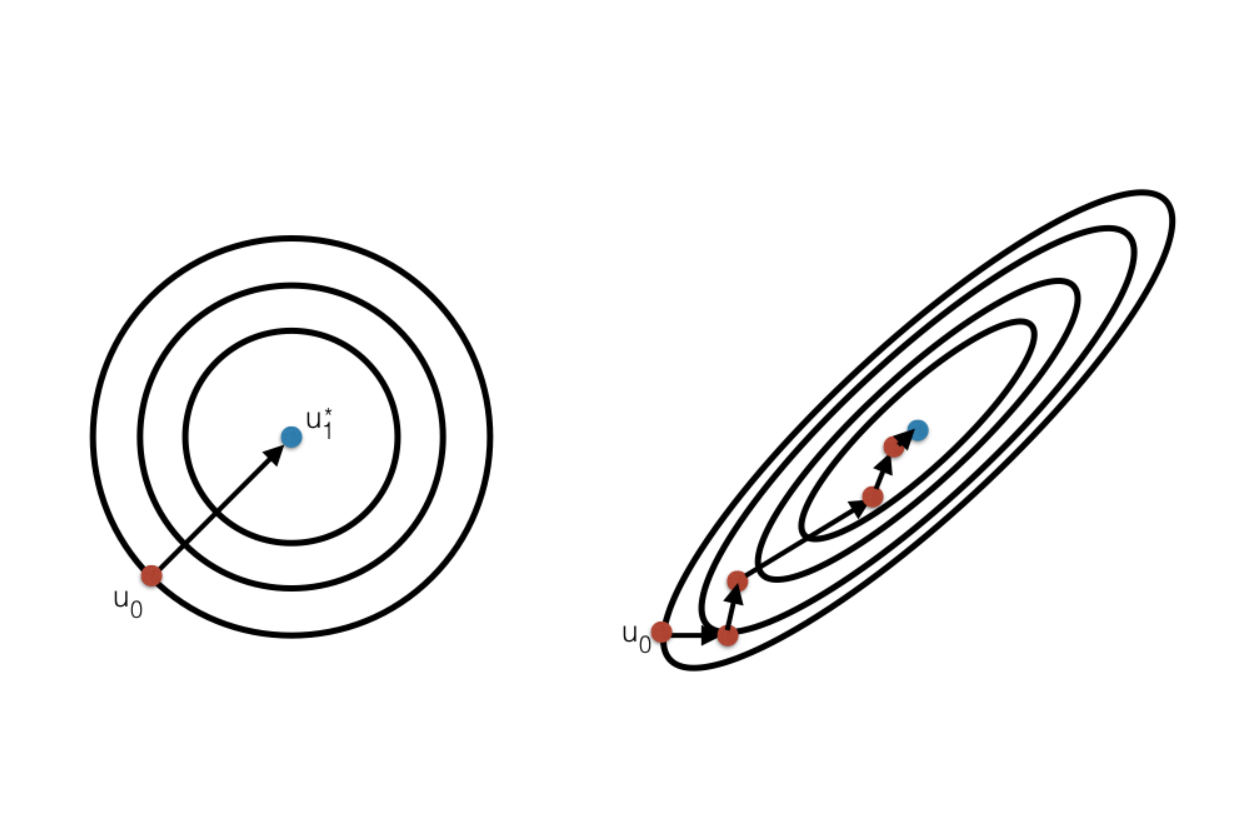

In [ ]:
def steepest_descent(A, U, b, axes):
    MAX_ITERATIONS = 10000
    tolerance = 1e-3
    success = False
    iteration_locations = []
    for k in range(MAX_ITERATIONS):
        axes.text(U[0] + 0.1, U[1] + 0.1, str(k), fontsize=12)
        axes.plot(U[0], U[1], 'ro')
        iteration_locations.append(U)
        r = b - numpy.dot(A, U)
        if numpy.linalg.norm(r, ord=2) < tolerance:
            success = True
            break

        alpha = numpy.dot(r, r) / numpy.dot(r, numpy.dot(A, r))
        U = U + alpha * r
        
    if success:
        return k, iteration_locations
    else:
        raise Exception("Iterasi tidak mencapai konvergensi.")

# Fungsi lambda untuk menghitung nilai phi
phi = lambda X, Y, A: 0.5 * (A[0, 0] * X**2 + A[0, 1] * X * Y + A[1, 0] * X * Y + A[1, 1] * Y**2) - X * f[0] - Y * f[1]

x = numpy.linspace(-15, 15, 100)
y = numpy.linspace(-15, 15, 100)
X, Y = numpy.meshgrid(x, y)

# Kasus 1: Matriks Identitas (Kontur Lingkaran)
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(1, 1, 1, aspect='equal')
A = numpy.identity(2)
f = numpy.array([0.0, 0.0])
k, iteration_locations = steepest_descent(A, numpy.array([-10.0, -12.0]), f, axes)
phi_levels = numpy.array([phi(U[0], U[1], A) for U in iteration_locations])
phi_levels.sort()
axes.contour(X, Y, phi(X, Y, A), levels=phi_levels, colors='r')
axes.contour(X, Y, phi(X, Y, A), 25)
print("Jumlah iterasi: %s" % k)

# Kasus 2: Matriks dengan angka kondisi rendah (Kontur Elips Moderat)
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(1, 1, 1, aspect='equal')
A = numpy.array([[2, -1], [-1, 2]])
f = numpy.array([1.0, 2.0])
k, iteration_locations = steepest_descent(A, numpy.array([-10.0, -12.0]), f, axes)
phi_levels = numpy.array([phi(U[0], U[1], A) for U in iteration_locations])
phi_levels.sort()
axes.contour(X, Y, phi(X, Y, A), levels=phi_levels, colors='r')
axes.contour(X, Y, phi(X, Y, A), 25)
print("Jumlah iterasi: %s" % k)

# Kasus 3: Matriks dengan angka kondisi tinggi (Kontur Elips Sangat Lonjong)
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(1, 1, 1, aspect='equal')
A = numpy.array([[2, -1.8], [-1.8, 2]])
f = numpy.array([1.0, 2.0])
k, iteration_locations = steepest_descent(A, numpy.array([-10.0, -12.0]), f, axes)
phi_levels = numpy.array([phi(U[0], U[1], A) for U in iteration_locations])
phi_levels.sort()
axes.contour(X, Y, phi(X, Y, A), levels=phi_levels, colors='r')
axes.contour(X, Y, phi(X, Y, A), 25)
print("Jumlah iterasi: %s" % k)

Masing-masing dari elips ini berkaitan dengan struktur eigen dari $A$ sedemikian rupa sehingga
$$
    A v_j - f = \lambda_j (v_j - u^\ast)
$$
untuk suatu $\lambda_j$. Mengetahui bahwa $A u^\ast = f$ menghasilkan
$$
    A (v_j - u^\ast) = \lambda_j (v_j - u^\ast)
$$
oleh karena itu $v_j - u^\ast$ membentuk vektor eigen dari matriks $A$ dengan nilai eigen $\lambda_j$ yang bersesuaian.

Jika sekumpulan $\lambda_j$ tertentu tidak berbeda (sama), maka elips tersebut sebenarnya adalah sebuah lingkaran, yang menunjukkan bahwa arah mana pun yang menunjuk ke $u^\ast$ dalam arah ini adalah vektor eigen (tidak unik dalam sub-ruang ini).

Kita juga dapat menghubungkan struktur eigen dan argumen geometris ini dengan angka kondisi matriks $\kappa$. Misalkan $v_1$ dan $v_2$ adalah vektor-vektor yang terletak di sepanjang kurva $\phi(u) = 1$, maka kita mendapatkan
$$
    \frac{1}{2} v^T_j A v_j - v_j^T A u^\ast = 1.
$$
Menggabungkan ekspresi ini dengan ekspresi vektor eigen sebelumnya dan melakukan perkalian titik (*inner-product*) dengan vektor eigen $v_j - u^\ast$ menghasilkan
$$
    ||v_j - u^\ast||^2_2 = \frac{2 + (u^\ast)^T A u^\ast}{\lambda_j}.
$$
Sekarang kembali ke $v_1$ dan $v_2$, kita mendapatkan rasionya sebagai
$$
    \frac{||v_1 - u^\ast||_2}{||v_2 - u^\ast||_2} = \sqrt{\frac{\lambda_2}{\lambda_1}} = \sqrt{\kappa_2(A)}.
$$
Ekspresi terakhir ini memberi tahu kita bahwa semakin berbentuk elips sub-ruang ini, maka akan semakin sulit untuk menyelesaikan $A u^\ast = f$.

### Interpretasi Proyeksi

Salah satu cara untuk menginterpretasikan metode *steepest descent* adalah sebagai metode proyeksi iteratif.

Katakanlah kita ingin menyelesaikan $A x = b$, di mana $A \in \mathbb R^{m \times m}$ dan $b \in \mathbb R^m$.

Mari kita asumsikan kita memiliki dua sub-ruang dalam $\mathbb R^m$: $\mathcal K$ sebagai sub-ruang pencarian (*search subspace*), dan $\mathcal L$ sebagai sub-ruang kendala (*subspace of constraints*). Kondisi
$$
    b - A x \perp \mathcal{L}
$$
menunjukkan bahwa vektor residu $b - A x$ tegak lurus (ortogonal) terhadap sub-ruang $\mathcal{L}$.

Tetapi bagaimana $\mathcal K$ berperan dalam hal ini? Modifikasi pernyataan aslinya sehingga
$$
    \tilde{x} \in \mathcal{K}
$$
dan kemudian
$$
    b - A \tilde{x} \perp \mathcal{L}.
$$
Ini dikenal sebagai kondisi *Petrov-Galerkin*.

Jika $\mathcal{K} = \mathcal{L}$, maka ini adalah sebuah proyeksi ortogonal.

Mengubah ini menjadi metode iteratif, biarkan tebakan awal kita menjadi $x^{(0)}$, maka
$$
    \tilde{x} \in x^{(0)} + \mathcal{K}
$$
sedemikian rupa sehingga
$$
    b - A \tilde{x} \perp \mathcal{L}.
$$
Perhatikan bahwa ini berarti kita memperluas ruang pencarian dengan bagian dari $\text{span}(x^{(0)})$ yang tidak termasuk dalam $\mathcal{K}$.

Kita dapat menulis ulang ini dalam bentuk yang lebih sugestif dengan memisalkan
$$
    \tilde{x} = x^{(0)} + \delta
$$
di mana $\delta \in \mathcal{K}$ adalah suatu vektor yang akan menjadi langkah kita. Berikan juga indeks pada vektor residu sehingga kita memiliki
$$
    r^{(k)} = b - A x^{(k)}
$$
pada langkah ke-$k$.

Kita kemudian merumuskan masalah baru sedemikian rupa sehingga
$$
    r^{(0)} - A \delta \perp \mathcal{L}
$$
yang mengarah pada pernyataan seperti iterasi:
$$\begin{aligned}
    \tilde{x} &= x^{(0)} + \delta, & \quad \quad & \delta \in \mathcal{K} \\
    (r^{(0)} - A \delta) \cdot w &= 0 & \quad \quad & \forall w \in \mathcal{L}
\end{aligned}$$

#### Contoh: Proyeksi Satu Dimensi

Metode proyeksi satu dimensi secara sederhana menyusun $\mathcal{K}$ dan $\mathcal{L}$ sedemikian rupa sehingga:
$$
    \mathcal{K} = \text{span}(v) \quad\quad \mathcal{L} = \text{span}(w)
$$
untuk dua buah vektor $v$ dan $w$. Dalam kasus ini, kita dapat menulis pembaruan (*update*) proyeksi sebagai
$$
    x^{(k+1)} = x^{(k)} + \alpha r
$$
di mana $r$ adalah residu dan 
$$
    \alpha = \frac{r \cdot w}{A v \cdot w}.
$$

Dalam kasus *steepest descent*, $v = w = r$. Perlu dicatat bahwa hal ini mengarah pada proyeksi ortogonal karena $\mathcal{K} = \mathcal{L}$.

Menggeneralisasi hal ini sedikit, kita dapat memikirkan metode *steepest descent* dalam konteks proyeksi. Misalkan $\mathcal{K} = \mathcal{L}$ dan asumsikan kembali bahwa $A$ adalah simetris positif-definit. Definisikan galat (*error*) pada langkah ke-$k$ sebagai
$$
    E^{(k)} = x^\ast - x^{(k)}.
$$

Dalam hal ini, pertimbangkan satu langkah dari $k=0$ ke $k=1$. Maka kita akan memiliki
$$
    r^{(1)} = b - A (x^{(0)} + \delta) = r^{(0)} - A \delta
$$
dan
$$
    A E^{(1)} = r^{(1)} = A(E^{(0)} - \delta)
$$
di mana $\delta$ adalah hasil dari proyeksi sehingga
$$ 
    (r^{(0)} - A \delta) \cdot w = 0 \quad \quad \forall w \in \mathcal{K}.
$$

### Arah Pencarian $A$-Konjugasi dan *Conjugate Gradient*

Alternatif untuk *steepest descent* adalah dengan memilih arah yang sedikit berbeda untuk menuruni fungsi. Menggeneralisasi langkah kita dari atas, biarkan skema iteratifnya menjadi
$$
    u^{(k+1)} = u^{(k)} - \alpha^{(k)} p^{(k)}
$$
dan seperti sebelumnya, kita ingin memilih $\alpha$ sedemikian rupa sehingga
$$
    \min_{\alpha} \phi(u^{(k)} - \alpha p^{(k)})
$$
yang kembali mengarahkan pada pilihan $\alpha$ yaitu
$$
    \alpha^{(k)} = \frac{(p^{(k)})^T p^{(k)}}{(p^{(k)})^T A p^{(k)}}
$$
kecuali bahwa sekarang kita juga diperbolehkan untuk memilih arah pencarian $p^{(k)}$.

Cara-cara untuk memilih $p^{(k)}$:
 - Salah satu pilihan yang buruk untuk $p$ adalah yang ortogonal terhadap $r$, karena hal ini akan menjadi tangen terhadap himpunan level (*level set* atau elips) dari $\phi(u^{(k)})$ dan akan menyebabkannya hanya meningkat, jadi kita ingin memastikan bahwa $p^T r \neq 0$ (perkalian titik).
 - Kita juga ingin tetap bergerak turun, sehingga mensyaratkan bahwa $\phi(u^{(k+1)}) < \phi(u^{(k)})$.

Kita tahu bahwa $r^{(k)}$ tidak selalu merupakan arah terbaik untuk dituju, tetapi apa yang mungkin lebih baik?

Kita bisa langsung menuju ke titik minimum, tetapi bagaimana cara melakukannya tanpa mengetahui $u^\ast$ terlebih dahulu?

Ternyata ketika $m=2$, kita dapat melakukannya dan dari tebakan awal $u^{(0)}$ serta arah awal $p^{(0)}$ mana pun, kita akan sampai pada titik minimum dalam 2 langkah jika kita memilih arah pencarian kedua bergantung pada
$$
    (p^{(1)})^T A p^{(0)} = 0.
$$
Secara umum, jika dua vektor memenuhi sifat ini, mereka dikatakan sebagai $A$-konjugat.
Perhatikan bahwa jika $A = I$, maka kedua vektor ini akan saling ortogonal satu sama lain, dan dalam pengertian ini, $A$-konjugasi adalah perluasan alami dari ortogonalitas dan kasus sederhana sebelumnya di mana elips adalah lingkaran ke kasus di mana kita bisa memiliki elips yang sangat terdistorsi.

Faktanya, vektor $p^{(0)}$ merupakan garis singgung (*tangent*) terhadap himpunan level di mana $u^{(1)}$ berada, dan oleh karena itu, memilih $p^{(1)}$ agar menjadi $A$-konjugat terhadap $p^{(0)}$ akan selalu mengarah ke pusat elips tersebut.

Untuk menunjukkan hal ini, ambil arah awal $p^{(0)}$ dan perhatikan bahwa ia bersinggungan dengan himpunan level $\phi$ di $u_1$, sehingga $p^{(0)}$ ortogonal terhadap residu. Melihat residu dari satu langkah, kita memiliki
$$
    r_1 = f - A u_1 = Au^\ast - A u_1 = A(u^\ast - u_1) \Rightarrow (p^{(0)})^T A (u^\ast - u_1) = 0.
$$

Dengan mengetahui bahwa $u^\ast - u_1 = \alpha p_1$, kita dapat menyimpulkan bahwa
$$
    p_0^T A p_1 = 0
$$
dengan asumsi $\alpha \neq 0$.

Fakta bahwa tebakan awal meminimalkan residu dalam arahnya sendiri adalah ide penting yang akan kita temui lagi.

Dengan kata lain, setelah kita mengetahui garis singgung pada salah satu elips, kita selalu dapat memilih arah yang meminimalkan salah satu dimensi dari ruang pencarian. Memilih $p^{(k)}$ secara iteratif dengan cara ini membentuk dasar dari metode **conjugate gradient**.

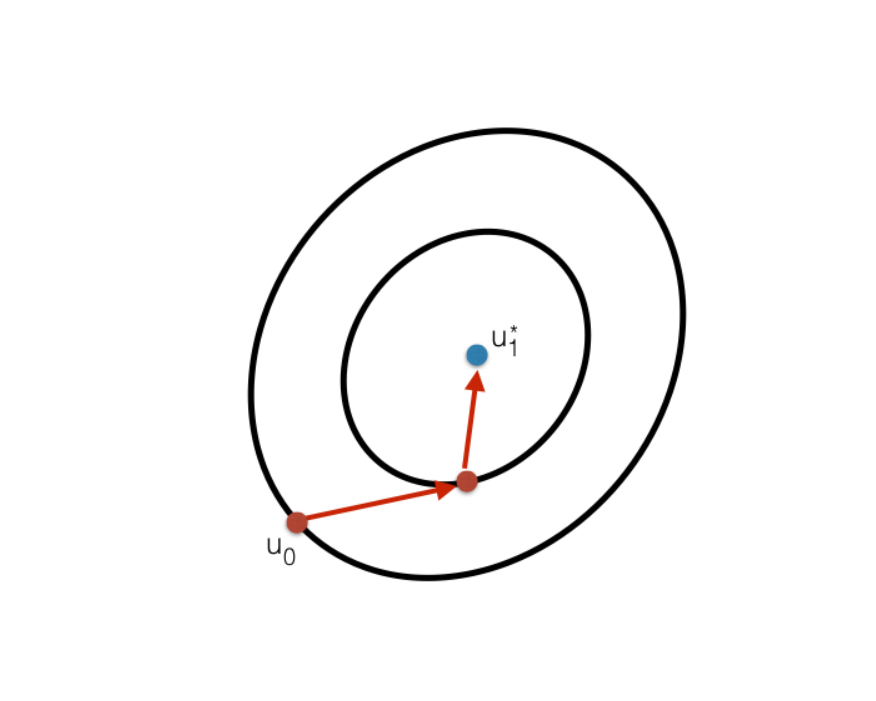

Sekarang untuk melakukan generalisasi melampaui $m = 2$, pertimbangkan kasus $m = 3$. Seperti yang dinyatakan sebelumnya, kita sekarang berada dalam ruang tiga dimensi di mana himpunan levelnya adalah elipsoid konsentris. Mengambil irisan melalui ruang ini akan menghasilkan sebuah elips pada irisan tersebut.

1. Mulailah dengan tebakan awal $u^{(0)}$ dan pilih arah pencarian $p^{(0)}$.
2. Minimalkan $\phi(u)$ dalam arah $u^{(0)} + \alpha p^{(0)}$ yang menghasilkan pilihan
$$
    \alpha^{(0)} = \frac{(p^{(0)})^T p^{(0)}}{(p^{(0)})^T A p^{(0)}}
$$
seperti yang kita lihat sebelumnya. Sekarang tetapkan $u^{(1)} = u^{(0)} + \alpha^{(0)} p^{(0)}$.
3. Pilih $p^{(1)}$ yang merupakan $A$-konjugat terhadap $p^{(0)}$. Dalam hal ini, terdapat kumpulan vektor tak terhingga yang mungkin memenuhi $(p^{(1)})^T A p^{(0)} = 0$. Selain mensyaratkan $p^{(1)}$ menjadi $A$-konjugat, kita juga ingin vektor tersebut bebas linier (*linearly-independent*) terhadap $p^{(0)}$.
4. Sekali lagi pilih $\alpha^{(1)}$ yang meminimalkan residu (kembali bersinggungan dengan himpunan level $\phi$) dalam arah $p^{(1)}$ dan ulangi prosesnya.

Jadi, mengapa ini bekerja jauh lebih baik daripada *steepest descent*?

Karena kita telah memilih $p^{(0)}$ dan $p^{(1)}$ agar bebas linier, keduanya merentang (*span*) sebuah sub-ruang dua dimensi dalam $\mathbb R^m$. Kita kemudian memilih untuk bergerak melalui sub-ruang ini untuk meminimalkan residu di dalam ruang tersebut. Secara geometris, kita telah memotong ruang dengan bidang ini yang menghasilkan sub-ruang dua dimensi dengan elips-elips konsentris yang merepresentasikan himpunan level dari $\phi$. Kita kemudian memilih $\alpha$ sehingga kita sampai di pusat dari elips-elips tersebut.

In [ ]:
# Pengaturan Masalah
a = 0.0
b = 1.0
alpha = 0.0
beta = 3.0
f = lambda x: numpy.exp(x)
u_sebenarnya = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)

# Diskritisasi
m = 50
x_bc = numpy.linspace(a, b, m + 2)
x = x_bc[1:-1]
delta_x = (b - a) / (m + 1)

# Membangun matriks A
A = numpy.zeros((m, m))
diagonal = numpy.ones(m) / delta_x**2
A += numpy.diag(diagonal * 2.0, 0)
A += numpy.diag(-diagonal[:-1], 1)
A += numpy.diag(-diagonal[:-1], -1)

# Membangun sisi ruas kanan (b)
b_vec = -f(x)
b_vec[0] += alpha / delta_x**2
b_vec[-1] += beta / delta_x**2

# Solusi eksak untuk sistem
U_eksak = numpy.linalg.solve(A, b_vec)

# Parameter algoritma
MAX_ITERATIONS = 10000
toleransi = delta_x**2

# Menyelesaikan sistem
U = numpy.zeros(m)
konvergensi_CG = numpy.zeros(MAX_ITERATIONS)
ukuran_langkah_CG = numpy.zeros(MAX_ITERATIONS)
norma_residu = numpy.zeros(MAX_ITERATIONS)
konvergensi_sistem = numpy.zeros(MAX_ITERATIONS)
berhasil = False

r = -(b_vec - numpy.dot(A, U))
p = -r
r_dot_r = numpy.dot(r, r)

for k in range(MAX_ITERATIONS):
    # Ukuran konvergensi
    U_lama = U.copy()
    r_lama = r.copy()
    
    if numpy.linalg.norm(r, ord=2) < toleransi:
        berhasil = True
        break
    
    A_dot_p = numpy.dot(A, p)
    
    # Panjang langkah
    alpha_langkah = r_dot_r / numpy.dot(p, A_dot_p)
    
    # Perbarui solusi dan residu
    U += alpha_langkah * p
    r += alpha_langkah * A_dot_p

    # Perbaikan solusi
    beta_faktor = numpy.dot(r, r) / r_dot_r
    r_dot_r = numpy.dot(r, r)
    
    # Pilih arah baru untuk iterasi berikutnya
    p = beta_faktor * p - r

    # Pengukuran konvergensi
    konvergensi_CG[k] = numpy.linalg.norm(u_sebenarnya(x) - U, ord=2)
    norma_residu[k] = numpy.linalg.norm(r, ord=2)
    ukuran_langkah_CG[k] = numpy.linalg.norm(U - U_lama, ord=2)
    konvergensi_sistem[k] = numpy.linalg.norm(U_eksak - U, ord=2)

if not berhasil:
    print("Iterasi gagal konvergen!")
    print(norma_residu[-10:])
    print(konvergensi_CG[-10:])
else:
    # Plot hasil
    fig = plt.figure()
    axes = fig.add_subplot(1, 1, 1)
    axes.plot(x, U, 'o', label="Dihitung")
    axes.plot(x_bc, u_sebenarnya(x_bc), 'k', label="Sebenarnya")
    axes.set_title("Solusi untuk $u_{xx} = e^x$")
    axes.set_xlabel("x")
    axes.set_ylabel("u(x)")

    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2.1)
    fig.set_figheight(fig.get_figheight() * 2.2)
    
    axes = fig.add_subplot(2, 2, 1)
    axes.semilogy(numpy.arange(1, k + 1), ukuran_langkah_CG[:k], 'o')
    axes.semilogy(numpy.arange(1, k + 1), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Ukuran Langkah")
    axes.set_xlabel("Iterasi")
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")
    
    axes = fig.add_subplot(2, 2, 2)
    axes.semilogy(numpy.arange(1, k + 1), konvergensi_CG[:k], 'o')
    axes.semilogy(numpy.arange(1, k + 1), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Konvergensi ke Solusi Sebenarnya")
    axes.set_xlabel("Iterasi")
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")

    axes = fig.add_subplot(2, 2, 3)
    axes.semilogy(numpy.arange(1, k + 1), norma_residu[:k], 'o')
    axes.semilogy(numpy.arange(1, k + 1), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Residu")
    axes.set_xlabel("Iterasi")
    axes.set_ylabel("$||r||_2$")

    axes = fig.add_subplot(2, 2, 4)
    axes.semilogy(numpy.arange(1, k + 1), konvergensi_sistem[:k], 'o')
    axes.semilogy(numpy.arange(1, k + 1), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Residu Sebenarnya")
    axes.set_xlabel("Iterasi")
    axes.set_ylabel("$||U^* - U||_2$")
    
    print("Angka kondisi matriks = %s" % (numpy.sqrt(numpy.linalg.norm(A) * numpy.linalg.norm(numpy.linalg.inv(A)))))
    
    plt.show()

In [ ]:
def CG(A, U, b, axes):
    MAX_ITERATIONS = A.shape[0] * 2
    tolerance = 1e-8
    success = False
    iteration_locations = []
    
    r = -(b - numpy.dot(A, U))
    p = -r
    r_dot_r = numpy.dot(r, r)
    for k in range(MAX_ITERATIONS):
        axes.text(U[0] + 0.1, U[1] + 0.1, str(k), fontsize=12)
        axes.plot(U[0], U[1], 'ro')
        iteration_locations.append(U)
        if numpy.linalg.norm(r, ord=2) < tolerance:
            success = True
            break

        A_dot_p = numpy.dot(A, p)

        # Panjang langkah
        alpha = r_dot_r / numpy.dot(p, A_dot_p)

        # Perbarui solusi dan residu
        U += alpha * p
        r += alpha * A_dot_p

        # Perbaikan solusi
        beta = numpy.dot(r, r) / r_dot_r
        r_dot_r = numpy.dot(r, r)

        # Pilih arah baru untuk iterasi berikutnya (jika diperlukan)
        p = beta * p - r
    
    if success:
        return k, iteration_locations
    else:
        raise Exception("Iterasi tidak mencapai konvergensi.")

# Fungsi phi
phi = lambda X, Y, A: 0.5 * (A[0, 0] * X**2 + A[0, 1] * X * Y + A[1, 0] * X * Y + A[1, 1] * Y**2) - X * f[0] - Y * f[1]

x = numpy.linspace(-15, 15, 100)
y = numpy.linspace(-15, 15, 100)
X, Y = numpy.meshgrid(x, y)

# Kasus 1: Matriks Identitas
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(1, 1, 1, aspect='equal')
A = numpy.identity(2)
f = numpy.array([0.0, 0.0])
k, iteration_locations = CG(A, numpy.array([-10.0, -12.0]), f, axes)
axes.contour(X, Y, phi(X, Y, A), 25)
print("Jumlah iterasi: %s" % k)

# Kasus 2: Matriks dengan korelasi sedang
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(1, 1, 1, aspect='equal')
A = numpy.array([[2, -1], [-1, 2]])
f = numpy.array([1.0, 2.0])
k, iteration_locations = CG(A, numpy.array([-10.0, -12.0]), f, axes)
axes.contour(X, Y, phi(X, Y, A), 25)
print("Jumlah iterasi: %s" % k)

# Kasus 3: Matriks dengan korelasi kuat (elips sangat lonjong)
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(1, 1, 1, aspect='equal')
A = numpy.array([[2, -1.8], [-1.8, 2]])
f = numpy.array([1.0, 2.0])
k, iteration_locations = CG(A, numpy.array([-10.0, -12.0]), f, axes)
axes.contour(X, Y, phi(X, Y, A), 25)
print("Jumlah iterasi: %s" % k)

Algoritma *conjugate gradient* membutuhkan $\mathcal{O}(m^2)$ operasi dan secara teori memerlukan $m$ iterasi untuk mencapai solusi eksak. Namun, dalam praktiknya, algoritma ini umumnya dapat konvergen jauh lebih cepat, terutama jika menggunakan prakondisi (*preconditioning*). Hal ini terutama berlaku untuk stensil Laplacian 5-titik dua dimensi yang telah kita lihat sebelumnya.

### Sub-ruang Krylov

Kita dapat memberikan banyak penjelasan mengenai kumpulan vektor $p^{(k)}$ yang merentang ruang di mana himpunan level $\phi$ berada, dimulai dengan teorema berikut.

**Teorema** Vektor-vektor yang dihasilkan dalam algoritma CG memiliki properti berikut, asalkan $r^{(k)} \neq 0$:
1. $p^{(k)}$ adalah $A$-konjugat terhadap semua arah pencarian sebelumnya.
2. Residu $r^{(k)}$ ortogonal terhadap semua residu sebelumnya $(r^{(k)})^T r_j = 0 \quad \forall j=0,1,\ldots$.
3. Ketiga sub-ruang $\mathbb R^m$ berikut adalah identik:
$$\begin{aligned}
    &\text{span} (p^{(0)}, p^{(1)}, \ldots, p^{(k-1)}) \\
    &\text{span} (r^{(0)}, A r^{(0)}, A^2 r^{(0)}, \ldots, A^{k-1} r^{(0)}) \\
    &\text{span} (A e^{(0)}, A^2 e^{(0)}, A^3 e^{(0)}, \ldots, A^{k} e^{(0)})
\end{aligned}$$

Sub-ruang $\mathcal{K}_k = \text{span} (r^{(0)}, A r^{(0)}, A^2 r^{(0)}, \ldots, A^{k-1} r^{(0)})$ yang direntang oleh vektor $r^{(0)}$ dan $k-1$ pangkat pertama dari $A$ terhadap $r^{(0)}$ disebut sebagai *ruang Krylov* berdimensi $k$ yang terkait dengan $r^{(0)}$.

### Proyeksi

Pembaruan baru $u^{(k)}$ dibentuk dengan menambahkan kelipatan dari $p^{(j)}$ ke tebakan awal $u^{(0)}$, sehingga ia berada dalam sub-ruang $u_0 + \mathcal{K}_k$. Cara lain untuk menuliskan ini adalah dengan menyatakan $u^{(k)} - u^{(0)} \in \mathcal{K}_k$. Perhatikan kemiripan antara hal ini dengan diskusi proyeksi kita sebelumnya.

### Konvergensi *Conjugate Gradient*

Sekarang kita beralih ke konvergensi CG dan menurunkan estimasi mengenai besarnya galat (*error*) pada $k$ tertentu serta laju konvergensinya.

Pertama, definisikan norma-$A$ sedemikian rupa sehingga
$$
    ||e||_A = \sqrt{e^T A e}
$$
dengan mengandalkan fakta bahwa $A$ adalah SPD (*Symmetric Positive-Definite*).

Hal ini menghasilkan
$$\begin{aligned}
    ||e||^2_A &= (u - u^\ast)^T A (u - u^\ast) \\
    &= u^T A u - 2 u^T A u^\ast + (u^\ast)^T A u^\ast \\
    &= 2 \phi(u) + (u^\ast)^T A u^\ast
\end{aligned}$$

Mengingat bahwa $(u^\ast)^T A u^\ast$ adalah sebuah konstanta, meminimalkan galat $||e||_A$ setara dengan meminimalkan $\phi(u)$.

Kita tahu bahwa kita dapat memperluas $u^{(k)}$ dalam sub-ruang $u_0 + \mathcal{K}_k$ sehingga
$$
    u^{(k)} = u^{(0)} + \alpha^{(0)} p^{(0)} + \alpha^{(1)} p^{(1)} + \cdots + \alpha^{(k-1)} p^{(k-1)}
$$
dan dengan mengurangkan $u^\ast$, kita temukan
$$
    u^{(k)} - u^\ast = e^{(k)} = e^{(0)} + \alpha^{(0)} p^{(0)} + \alpha^{(1)} p^{(1)} + \cdots + \alpha^{(k-1)} p^{(k-1)}
$$
yang menghubungkan $e^{(k)}$ dan $e^{(0)}$ serta menyiratkan bahwa $e^{(k)} - e^{(0)} \in \mathcal{K}_k$.

Berdasarkan teorema di atas, kita juga mengetahui bahwa
$$
    e^{(k)} - e^{(0)} \in \text{span} (A e^{(0)}, A^2 e^{(0)}, A^3 e^{(0)}, \ldots, A^{k} e^{(0)})
$$
sehingga
$$
    e^{(k)} = e^{(0)} + c_1 A e^{(0)} + c_2 A^2 e^{(0)} + \cdots + c_k A^k e^{(0)}
$$
di mana $c_j$ adalah beberapa koefisien (yang ditemukan dengan mengambil proyeksi $e^{(k)}$ ke dalam *span* tersebut).

Hal ini kemudian mengarah pada
$$
    e^{(k)} = P_k(A) e^{(0)}
$$
di mana
$$
    P_k(A) = I + c_1 A + c_2 A^2 + \cdots + c_k A^k.
$$
Perhatikan bahwa $P_k(A)$ adalah polinomial dalam $A$. Kita dapat menghubungkan ini dengan polinomial skalar dengan memisalkan
$$
    P_k(x) = 1 + c_1 x + c_2 x^2 + \cdots + c_k x^k
$$
sehingga $P_k \in \mathcal{P}_k$ di mana $\mathcal{P}_k$ adalah polinomial dengan derajat paling tinggi $k$ dan $P(0) = 1$.

CG secara implisit menyusun polinomial $P_k$ dan menyelesaikan masalah minimisasi terkait
$$
    \min_{P \in \mathcal{P}_k} ||P(A) e^{(0)}||_A.
$$

#### Apa itu polinomial matriks?

Jika kita tahu bahwa matriks kita dapat didiagonalisasi, kita dapat menulis diagonalisasi ini sebagai
$$
    A = V \Lambda V^{-1}.
$$

Jika kita mengambil pangkat dari $A$, maka kita temukan
$$
    A^k = (V \Lambda V^{-1})^k = V \Lambda V^{-1} V \Lambda V^{-1} \cdots V \Lambda V^{-1} = V \Lambda^k V^{-1}.
$$

Polinomial dalam $A$ kemudian dapat ditulis sebagai
$$
    P_k(A) = V P_k(\Lambda) V^{-1}
$$
sehingga
$$
    P_k(\Lambda) = \begin{bmatrix}
        P_k(\lambda_1) \\
        & P_k(\lambda_2) \\
        & & P_k(\lambda_3) \\
        & & & \ddots \\
        & & & & P_k(\lambda_m)
    \end{bmatrix}.
$$

Sekarang kembali ke ekspresi kita untuk galat (*error*), kita memiliki
$$
    e^{(k)} = P_k(A) e^{(0)}.
$$
Jika polinomial $P_k(A)$ memiliki akar di setiap $\lambda_k$, maka $P_k(\Lambda)$ adalah matriks nol dan ekspresi galat di atas membawa kita pada kesimpulan bahwa $e^{(k)} = 0$. Jika nilai eigen berulang (katakanlah kita memiliki $n$ nilai eigen unik, ini dikenal sebagai multiplisitas geometris), maka kita dapat katakan bahwa terdapat lagi polinomial $P_n \in \mathcal{P}_n$ yang juga memiliki akar-akar ini dan kita mengharapkan $e^{(n)} = 0$, kita konvergen lebih cepat daripada dimensi $A$!

Katakanlah kita ingin tahu seberapa besar galatnya sebelum iterasi yang menjamin konvergensi? Kita ingin tahu bagaimana perilaku $||e^{(0)}||_A$. Ternyata untuk setiap $P \in \mathcal{P}$ kita memiliki
$$
    \frac{||P(A)e^{(0)}||_A}{||e^{(0)}||_A} \leq \max_{1 \leq j \leq m} |P(\lambda_j)|.
$$
Kita kemudian perlu menemukan satu polinomial $\hat{P_k} \in \mathcal{P}_k$ sehingga kita bisa mendapatkan batas (*bound*) yang berguna untuk $||e^{(k)}||_A / ||e^{(0)}||_A$.

Cukup mengejutkan bahwa versi Polinomial Chebyshev $T_k(x)$ yang digeser dan diskalakan akan berhasil untuk ini! Dengan menetapkan
$$
    \hat{P_k}(x) = \frac{T_k\left(\frac{\lambda_m + \lambda_1 - 2x}{\lambda_m - \lambda_1} \right )}{T_k\left(\frac{\lambda_m + \lambda_1}{\lambda_m - \lambda_1}\right ) }
$$

dan menghitung 
$$
    \max_{1\leq j \leq m} \left |\hat{P_k}(\lambda_j) \right|.
$$

Dengan beberapa analisis (rujuk ke LeVeque untuk penurunan lengkapnya), kita dapat menunjukkan bahwa 
$$
    T_k(x) = \frac{1}{2} \left[ \left ( \frac{\sqrt{\kappa} + 1}{\sqrt{\kappa} - 1} \right)^k + \left ( \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1} \right)^k \right ]
$$
dan
$$
    \frac{||P(A) e^{(0)}||_A}{||e^{(0)}||_A} \leq 2 \left[ \left ( \frac{\sqrt{\kappa} + 1}{\sqrt{\kappa} - 1} \right)^k + \left ( \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1} \right)^k \right ]^{-1} \leq 2 \left ( \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1} \right)^k
$$
di mana $\kappa$ adalah angka kondisi matriks.

Jika angka kondisi matriks $\kappa$ bernilai besar, kita juga dapat menyederhanakan batasan kita menjadi
$$
    2 \left ( \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1} \right)^k \approx 2 \left ( 1 - \frac{2}{\sqrt{\kappa}} \right)^k \approx 2 e^{-2 k / \sqrt{\kappa}}.
$$
Ini menyiratkan bahwa perkiraan jumlah iterasi $k$ untuk mencapai toleransi yang diinginkan adalah $k = \mathcal{O}\left(\sqrt{\kappa}\right)$.



### Prakondisi (*Preconditioning*)

Salah satu cara untuk mengatasi kesulitan pada jenis metode ini akibat distorsi elips (dan konsekuensinya pada pengkondisian matriks) adalah dengan memberikan prakondisi pada matriks tersebut. Ide dasarnya adalah kita mengambil masalah asli kita $A u = f$ dan sebagai gantinya menyelesaikan
$$
    M^{-1} A u = M^{-1} f.
$$
Perhatikan bahwa karena kita perlu mencari invers dari $M$, matriks ini haruslah matriks yang "baik" (mudah diolah). Beberapa contoh ilustrasi mungkin membantu menjelaskan mengapa ini ide yang bagus:

 - Jika $M = A$, maka pada dasarnya kita sudah menyelesaikan masalah kita, meskipun itu tidak banyak membantu.
 - Jika $M = \text{diag}(A)$, maka $M^{-1}$ dapat dihitung dengan mudah dan ternyata untuk beberapa masalah, hal ini dapat menurunkan angka kondisi $M^{-1} A$ secara signifikan. Namun, perlu dicatat bahwa ini tidak terlalu membantu dalam kasus masalah Poisson.
 - Jika $M$ didasarkan pada metode iteratif lain yang digunakan pada $A$, misalnya Gauss-Seidel, ini bisa menjadi prakondisi penggunaan umum yang efektif untuk banyak masalah.
 
Jadi, pertanyaan berikutnya adalah bagaimana cara memilih prakondisi. Hal ini biasanya sangat spesifik untuk masalah tertentu dan banyak makalah menyarankan strategi untuk masalah-masalah khusus. Secara umum, kita ingin menggeser nilai-nilai eigen sehingga matriks tidak terlalu berkondisi buruk (*ill-conditioned*). Menggabungkan prakondisi dengan CG menghasilkan metode PCG yang populer.

## Algoritma *Generalized Minimum Residual* (GMRES)

Bagaimana jika sistem kita tidak simetris positif (atau negatif) definit?

Panik!

(Atau jangan panik jika Anda membawa handuk dan buku panduan tertentu).
Sebenarnya tidak perlu. GMRES adalah salah satu pendekatan untuk menyelesaikan masalah ini bagi kita. Karena kita tidak bisa lagi bergantung pada struktur masalah minimisasi skalar yang terkait, kita akan meminimalkan residu dalam sub-ruang yang sama seperti sebelumnya menggunakan pendekatan kuadrat terkecil (*least-squares*).

Pada iterasi ke-$k$, GMRES menyelesaikan masalah kuadrat terkecil dalam sub-ruang tertentu dari masalah utamanya. Dalam kasus ini, kita akan menggunakan ruang yang kita lihat sebelumnya, $u_0 + \mathcal{K}_k$, di mana $\mathcal{K}$ didefinisikan sebagai
$$
    \mathcal{K}_k = \text{span} (r^{(0)}, A r^{(0)}, A^2 r^{(0)}, \ldots, A^{k-1} r^{(0)}).
$$

Untuk melakukan ini, kita membangun sebuah matriks $Q$ yang kolom-kolomnya berisi sekumpulan vektor ortonormal yang merentang ruang $\mathcal{K}_k$. Karena ini bersifat iteratif, setiap kali kita menambah $k$, kita hanya perlu mencari satu vektor tambahan bagi $Q$ untuk merentang ruang berikutnya.

Dimulai dengan iterasi ke-$k$, kita memiliki
$$
    Q = [q_1 q_2 q_3 \cdots q_k] \in \mathbb R^{m \times k}.
$$
Pilih sebuah vektor $v_j \notin \mathcal{K}_k$ dan gunakan Gram-Schmidt (atau metode serupa) untuk mengortogonalkan vektor ini terhadap semua $q_i$ lainnya.
Apa yang harus kita pilih untuk $v_j$?

Ada beberapa pilihan buruk seperti $v_k = A^k r^{(k)}$ (ini berhasil tetapi menghasilkan nilai singular yang sangat kecil).

Sebaliknya, kita akan memilih $v_k = A q_k$. Secara efektif, kita sedang membangun faktorisasi dari matriks $A$. Proses ini disebut *proses Arnoldi*.



### Proses Arnoldi

Proses Arnoldi membangun basis ortogonal dari sub-ruang Krylov $\mathcal{K}_m$. Kita dapat menggunakan algoritma apa pun untuk mencari ortogonalisasi (misalnya Gram-Schmidt). Pada intinya, kita memiliki prosedur berikut:

Inisialisasi proses dengan vektor $v_0$ dengan $||v_0|| = 1$. Sekarang ulangi langkah-langkah berikut:
1. $w_k = A v_{k-1}$
2. Ortogonalkan vektor $w_k$ terhadap semua $v_j$ sebelumnya ($j < k$).
3. Berhenti ketika $w_k$ menghilang (bernilai nol).

Proses ini secara praktis menciptakan transformasi berikut
$$
    A V_m = V_m H_m
$$
di mana $V_m$ adalah matriks $m \times m$ dengan kolom-kolomnya berupa vektor $v_j$ yang telah dihitung, dan $H_m$ adalah matriks Hessenberg $(m + 1) \times m$ yang entri-entri tidak nolnya adalah $h_{ij}$ yang didefinisikan sebagai $h_{ij} = A v_j \cdot v_i$ dan $h_{j+1,j} = ||w_j||_2$ dengan penghapusan baris terakhir. Ini mendeskripsikan proses ortogonalisasi secara tepat.



Sekarang bagaimana kita menerapkannya? Diberikan tebakan awal $x^{(0)}$, pertimbangkan metode proyeksi ortogonal di mana
$$
    \mathcal{L} = \mathcal{K} = \mathcal{K}_m(A, r^{(0)})
$$
di mana sub-ruang Krylov-nya adalah
$$
    \mathcal{K}_m(A, r^{(0)}) = \text{span}\{r^{(0)}, A r^{(0)}, A^2 r^{(0)}, \ldots,A^{m-1} r^{(0)} \}.
$$

Misalkan $v_1 = r^{(0)} / || r^{(0)} ||_2$ dan terapkan metode Arnoldi, maka kita akan mendapatkan
$$
    V^T_m A V_m = H_m
$$
yang juga menyiratkan bahwa
$$
    V^T_m r^{(0)} = V^T_m (\beta v_1) = \beta e_1
$$
di mana $\beta = ||r^{(0)}||_2$. Kita kemudian dapat menemukan
$$
    x_m = x^{(0)} + V_m y_m \\
    y_m = H^{-1}_m (\beta e_1)
$$

Algoritma ini setara dengan *Conjugate Gradient* ketika matriksnya bersifat SPD.

Perlu dicatat juga bahwa dalam kasus matriks simetris, matriks Hessenberg $H$ juga simetris, yang menyiratkan bahwa matriks tersebut berbentuk tri-diagonal, sehingga sangat menyederhanakan hasil umum kita.

In [ ]:
def arnoldi(A, b):
    n = b.shape[0]
    q = [0] * n
    q[0] = b / numpy.linalg.norm(b)
    h = numpy.zeros((n + 1, n))
    for k in range(n):
        v = numpy.dot(q[k], A).reshape(-1)
        for j in range(k):
            h[j, k] = numpy.dot(q[j], v.T)
            v = v - h[j, k] * q[j]      
        h[k + 1, k] = numpy.linalg.norm(v)
        if (h[k + 1, k] != 0 and k != n - 1):
            q[k + 1] = v / h[k + 1, k]
    
    return h

# Pengaturan Masalah
a = 0.0
b_val = 1.0 # Mengubah nama variabel agar tidak bentrok dengan vektor b
alpha = 0.0
beta_val = 3.0
f = lambda x: numpy.exp(x)
u_sebenarnya = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)

# Diskritisasi
m = 100
x_bc = numpy.linspace(a, b_val, m + 2)
x = x_bc[1:-1]
delta_x = (b_val - a) / (m + 1)

# Membangun matriks A
A = numpy.zeros((m, m))
diagonal = numpy.ones(m) / delta_x**2
A += numpy.diag(diagonal * 2.0, 0)
A += numpy.diag(-diagonal[:-1], 1)
A += numpy.diag(-diagonal[:-1], -1)

# Membangun sisi ruas kanan (b)
b = -f(x)
b[0] += alpha / delta_x**2
b[-1] += beta_val / delta_x**2

U = numpy.zeros(m + 2)
U[0] = alpha
U[-1] = beta_val

# Menghitung matriks Hessenberg
H = arnoldi(A, b)

# Menyelesaikan masalah minimisasi yang dihasilkan
e_1 = numpy.zeros(m)
e_1[0] = 1.0
# Catatan: Bagian ini ditandai "NOT WORKING" di kode asli karena H adalah (m+1) x m
# Biasanya membutuhkan penyelesaian kuadrat terkecil (least squares)
# y = numpy.linalg.solve(H, beta_val * e_1) 

# (Bagian yang dikomentari di bawah ini adalah implementasi alternatif 
# menggunakan Modified Gram-Schmidt)

# Plot hasil
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Dihitung")
axes.plot(x_bc, u_sebenarnya(x_bc), 'k', label="Sebenarnya")
axes.set_title("Solusi untuk $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
plt.show()

## Multigrid
### Meninjau Kembali Jacobi

Pertimbangkan masalah Poisson dengan
$$
    f(x) = -20 + \frac{1}{2}\left ( \phi''(x) \cos \phi(x) -  (\phi'(x))^2 \sin \phi(x) \right )
$$
dengan
$$
    \phi = 20 \pi x^3,
$$
dan kondisi batas $u(0) = 1$ serta $u(1) = 3$.

Dengan mengintegrasikannya dua kali, kita dapat menemukan bahwa solusi dari masalah ini adalah
$$
    u(x) = 1 + 12 x - 10 x^3 + \frac{1}{2} \sin \phi(x).
$$

Mendiskritisasi masalah ini dengan cara standar menggunakan beda hingga terpusat orde kedua menghasilkan kode berikut:

In [ ]:
def jacobi_update(x, U, f, delta_x):
    """Perbarui U dengan satu iterasi Jacobi tunggal"""
    U_baru = U.copy()
    for i in range(1, x.shape[0] - 1):
        U_baru[i] = 0.5 * (U[i+1] + U[i-1]) - f(x[i]) * delta_x**2 / 2.0
    ukuran_langkah = numpy.linalg.norm(U_baru - U, ord=2)
    del(U)
    return U_baru, ukuran_langkah


# Pengaturan Masalah
a = 0.0
b = 1.0
alpha = 1.0
beta = 3.0
phi = lambda x: 20.0 * numpy.pi * x**3
phi_aksen = lambda x: 60.0 * numpy.pi * x**2
phi_aksen_ganda = lambda x: 120.0 * numpy.pi * x
f = lambda x: -20.0 + 0.5 * (phi_aksen_ganda(x) * numpy.cos(phi(x)) - (phi_aksen(x))**2 * numpy.sin(phi(x)))
u_sebenarnya = lambda x: 1.0 + 12.0 * x - 10.0 * x**2 + 0.5 * numpy.sin(phi(x))

# Diskritisasi
m = 100
x_bc = numpy.linspace(a, b, m + 2)
x = x_bc[1:-1]
delta_x = (b - a) / (m + 1)

# Perkiraan jumlah iterasi yang dibutuhkan
iterasi_J = int(2.0 * numpy.log(delta_x) / numpy.log(1.0 - 0.5 * numpy.pi**2 * delta_x**2))
# iterasi_J = 100

# Menyelesaikan sistem
# Tebakan awal untuk iterasi
U = 1.0 + 2.0 * x_bc
U[0] = alpha
U[-1] = beta
konvergensi_J = numpy.zeros(iterasi_J)
ukuran_langkah = numpy.zeros(iterasi_J)
for k in range(iterasi_J):
    U, ukuran_langkah[k] = jacobi_update(x_bc, U, f, delta_x)
    konvergensi_J[k] = numpy.linalg.norm(delta_x * (u_sebenarnya(x_bc) - U), ord=2)

# Plot hasil
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)

axes = fig.add_subplot(1, 3, 1)
axes.plot(x_bc, U, 'o', label="Dihitung")
axes.plot(x_bc, u_sebenarnya(x_bc), 'k', label="Sebenarnya")
axes.set_title("Solusi untuk $u_{xx} = f(x)$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")

axes = fig.add_subplot(1, 3, 2)
axes.semilogy(list(range(iterasi_J)), konvergensi_J, 'o')
axes.set_title("Galat (Error)")
axes.set_xlabel("Iterasi")
axes.set_ylabel("$||U^{(k)} - u(x)||_1$")

axes = fig.add_subplot(1, 3, 3)
axes.semilogy(list(range(iterasi_J)), ukuran_langkah, 'o')
axes.set_title("Perubahan Setiap Langkah")
axes.set_xlabel("Iterasi")
axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")

plt.show()

Kita pada akhirnya memang mencapai konvergensi, meskipun kita melihat adanya batas bawah terhadap efektivitas iterasi Jacobi. Kita juga kembali mengamati konvergensi yang sangat lambat seperti yang telah diperkirakan. Namun, bagaimana jika kita tetap bisa memanfaatkan keunggulan Jacobi?

Kuncinya terletak pada pemahaman tentang apa yang sebenarnya dihaluskan oleh Jacobi dengan cepat.

In [ ]:
# Pengaturan Masalah
a = 0.0
b = 1.0
alpha = 1.0
beta = 3.0
phi = lambda x: 20.0 * numpy.pi * x**3
phi_aksen = lambda x: 60.0 * numpy.pi * x**2
phi_aksen_ganda = lambda x: 120.0 * numpy.pi * x
f = lambda x: -20.0 + 0.5 * (phi_aksen_ganda(x) * numpy.cos(phi(x)) - (phi_aksen(x))**2 * numpy.sin(phi(x)))
u_sebenarnya = lambda x: 1.0 + 12.0 * x - 10.0 * x**2 + 0.5 * numpy.sin(phi(x))

# Diskritisasi
m = 255
x_bc = numpy.linspace(a, b, m + 2)
x = x_bc[1:-1]
delta_x = (b - a) / (m + 1)

U = 1.0 + 2.0 * x_bc
U[0] = alpha
U[-1] = beta

jumlah_langkah = 1000
frekuensi_plot = 200

# Plot galat awal (iterasi 0)
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)

axes = fig.add_subplot(1, 2, 1)
axes.plot(x_bc, U, 'o', label="Dihitung")
axes.plot(x_bc, u_sebenarnya(x_bc), 'k', label="Sebenarnya")
axes.set_title("Solusi untuk $u_{xx} = f(x)$, iterasi = %s" % 0)
axes.set_xlabel("x")
axes.set_ylabel("u(x)")

axes = fig.add_subplot(1, 2, 2)
axes.plot(x_bc, U - u_sebenarnya(x_bc), 'r-o')
axes.set_title("Galat, iterasi = %s" % 0)
axes.set_xlabel("x")
axes.set_ylabel("U - u")

# Mulai iterasi Jacobi
for k in range(jumlah_langkah):
    U, ukuran_langkah = jacobi_update(x_bc, U, f, delta_x)

    if (k+1) % frekuensi_plot == 0:
        print(ukuran_langkah)
        fig = plt.figure()
        fig.set_figwidth(fig.get_figwidth() * 2)

        axes = fig.add_subplot(1, 2, 1)
        axes.plot(x_bc, U, 'o', label="Dihitung")
        axes.plot(x_bc, u_sebenarnya(x_bc), 'k', label="Sebenarnya")
        axes.set_title("Solusi untuk $u_{xx} = f(x)$, iterasi = %s" % (k + 1))
        axes.set_xlabel("x")
        axes.set_ylabel("u(x)")

        axes = fig.add_subplot(1, 2, 2)
        axes.plot(x_bc, U - u_sebenarnya(x_bc), 'r-o')
        axes.set_title("Galat, iterasi = %s" % (k + 1))
        axes.set_xlabel("x")
        axes.set_ylabel("U - u")

plt.show()

Perhatikan bahwa komponen galat dengan frekuensi yang lebih tinggi dihilangkan lebih dulu! Mengapa demikian?

Ingat kembali bahwa secara umum kita menemukan bahwa galat $e^{(k)}$ dari pendekatan iteratif pemisahan matriks melibatkan matriks $G$ di mana
$$
    U^{(k+1)} = M^{-1} N U^{(k)} + M^{-1} b = G U^{(k)} + c.
$$
Kita kemudian tahu bahwa
$$
    e^{(k)} = G e^{(k-1)}.
$$

Dalam kasus Jacobi, matriks $G$ dapat ditulis sebagai
$$
    G = I + \frac{\Delta x^2}{2} A = \begin{bmatrix}
        0 & 1/2 & \\
        1/2 & 0 & 1/2 \\
         & 1/2 & 0 & 1/2 \\
         & & \ddots & \ddots & \ddots \\
         & & & 1/2 & 0 & 1/2 \\
         & & & & 1/2 & 0
    \end{bmatrix}
$$
Perhatikan bahwa ini sama saja dengan merata-ratakan suku-suku di luar diagonal $U_{i+1}$ dan $U_{i-1}$. Perataan (averaging) memiliki efek penghalusan (*smoothing*), yaitu meredam frekuensi yang lebih tinggi dengan lebih cepat.



Ingat bahwa vektor eigen dari $A$ dan $G$ adalah sama; jika vektor eigen tersebut adalah
$$
    u^p_j = \sin(\pi p x_j) \quad \text{dengan} \quad x_j = j \Delta x, \quad j = 1, 2, 3, \ldots, m.
$$
dengan nilai eigen
$$
    \lambda_p = \cos(p \pi \Delta x).
$$

Kita dapat memproyeksikan galat awal $e^{(0)}$ ke dalam ruang eigen sehingga
$$
    e^{(0)} = c_1 u^1 + c_2 u^2 + \cdots + c_m u^m
$$
dan oleh karena itu
$$
    e^{(k)} = c_1 (\lambda_1)^k u^1 + c_2 (\lambda_2)^k u^2 + \cdots + c_m (\lambda_m)^k u^m.
$$

Ini menyiratkan bahwa komponen ke-$p$ dari vektor $e^{(k)}$ meluruh sesuai dengan nilai eigen yang bersesuaian.

Memeriksa nilai eigen tersebut, kita tahu bahwa nilai eigen ke-1 dan ke-$m$ akan paling dekat dengan 1, sehingga suku $c_1 (\lambda_1)^k u^1$ dan $c_m (\lambda_m)^k u^m$ akan mendominasi galat karena
$$
    \lambda_1 = -\lambda_m \approx 1- \frac{1}{2} \pi^2 \Delta x^2.
$$
Kita telah melihat ini sebelumnya karena hal ini menentukan laju konvergensi keseluruhan untuk Jacobi.

Untuk komponen galat lainnya, kita dapat melihat secara kasar seberapa cepat mereka akan meluruh. Jika $m / 4 \leq p \leq 3m / 4$ maka
$$
    |\lambda_p| \leq \frac{1}{\sqrt{2}} \approx 0.7
$$
menyiratkan bahwa setelah 20 iterasi kita akan memiliki $|\lambda_p|^{20} < 10^{-3}$.

Menghubungkan ini kembali ke anggapan awal kita bahwa frekuensi tingkat tinggi dalam galat diredam lebih cepat, lihatlah bentuk komponen vektor eigen tersebut. Galat asli diproyeksikan ke vektor eigen sehingga
$$
    e^{(0)} = c_1 u^1 + c_2 u^2 + \cdots + c_m u^m,
$$
dengan memasukkan vektor eigen itu sendiri, kita temukan
$$
    e^{(0)} = c_1 \sin(\pi x_j) + c_2 \sin(\pi 2 x_j) + \cdots + c_m \sin(\pi m x_j)
$$
sehingga kita secara efektif telah menguraikan galat asli dalam bentuk deret sinus Fourier.

Sekarang dengan mempertimbangkan analisis kita pada nilai eigen, kita melihat bahwa sebenarnya rentang frekuensi menengahlah yang meluruh paling cepat. Alasan mengapa kita tidak melihat hal ini dalam contoh kita adalah karena solusinya tidak mengandung frekuensi tingkat tinggi relatif terhadap pilihan $m$ kita. Jika kita memilih $m$ yang terlalu kecil, kita akan mendapat masalah (karena berbagai alasan). Cobalah sendiri dan lihat apa yang Anda amati.

Ternyata hanya memiliki rentang menengah yang meluruh dengan cepat adalah suboptimal dalam konteks yang kita pertimbangkan. Sebaliknya, kita akan menggunakan *underrelaxed Jacobi*, serupa dengan SOR dari sebelumnya, di mana
$$
    U^{(k+1)} = (1 - \omega) U^{(k)} + \omega G U^{(k)}
$$
dengan $\omega = 2/3$ (di mana $G$ adalah matriks iterasi Jacobi). Matriks iterasi yang baru adalah
$$
    G_\omega = (1 - \omega) I + \omega G
$$
dan memiliki nilai eigen
$$
    \lambda_p = (1-\omega)+\omega \cos (p \pi \Delta x).
$$

Pilihan $\omega$ ini pada kenyatannya meminimalkan nilai eigen dalam rentang $m/2 < p < m$. Faktanya
$$
    |\lambda_p| \leq 1/3
$$
untuk rentang ini. Sebagai metode mandiri, ini sebenarnya lebih buruk daripada Jacobi karena komponen galat frekuensi rendah meluruh bahkan lebih lambat dari sebelumnya, tetapi perilaku ini sangat sempurna untuk pendekatan *multigrid*.

### Pendekatan Multigrid
Pendekatan dasar untuk multigrid adalah melakukan langkah-langkah berikut:

1. Gunakan beberapa iterasi *underrelaxed Jacobi* untuk meredam komponen galat (*error*) frekuensi tinggi.
2. Karena galat sekarang lebih halus daripada sebelumnya, kita dapat merepresentasikan solusi (dan galat) pada kisi (*grid*) dengan resolusi yang lebih kasar. Kita kemudian beralih ke resolusi yang lebih kasar tersebut.
3. Pada kisi yang lebih kasar ini, kita kembali menerapkan beberapa iterasi *underrelaxed Jacobi* yang sekarang akan menghilangkan sekumpulan komponen galat frekuensi rendah dengan cepat karena kita berada di kisi yang lebih kasar.

Pertimbangkan komponen $p = m/4$ yang pada kisi asli tidak akan banyak diredam karena berada dalam rentang frekuensi rendah. Jika kita mentransfer masalah tersebut ke kisi dengan jumlah titik setengah kali lebih sedikit, kita akan mendapati bahwa frekuensi sebelumnya kini berada di titik tengah rentang frekuensi dan oleh karena itu akan diredam jauh lebih cepat!

Satu poin penting di sini adalah alih-alih mentransfer solusi ke kisi yang lebih kasar, kita hanya mentransfer **galatnya**.

Jika kita telah melakukan $n$ iterasi pada kisi asli, kita sekarang akan memiliki:
$$
    e^{(n)} = U^{(n)} - u
$$
yang memiliki vektor residu:
$$
    r^{(n)} = f - A U^{(n)}
$$
karena
$$
    A e^{(n)} = -r^{(n)}.
$$
Jika kita dapat menyelesaikan sistem ini untuk $e^{(n)}$, maka kita bisa kembali dan cukup mengurangkannya dari persamaan yang menghubungkan solusi numerik $U^{(n)}$ kita dengan $u$. Sistem persamaan yang menghubungkan galat dan residu inilah yang ingin kita "kasarkan" (*coarsening*).



#### Algoritma Dasar:
1. Lakukan $n$ iterasi (di mana $n$ ditetapkan) dari metode iteratif sederhana pada masalah asli $A u = f$. Ini memberikan solusi perkiraan $U^{(n)} \in \mathbb R^m$.
2. Hitung residu $r^{(n)} = f - A U^{(n)} \in \mathbb R^m$.
3. Lakukan pengasaran (*coarsening*) pada masalah residu, pindahkan $r^{(n)} \in \mathbb R^m$ ke $\hat{r} \in \mathbb R^{m_c}$ di mana $m_c = (m - 1) / 2$.
4. Selesaikan secara perkiraan masalah baru $\hat{A} \hat{e} = -\hat{r}$ di mana $\hat{A}$ adalah matriks $A$ yang telah diskalakan dengan tepat.
5. Kita sekarang memiliki perkiraan galat $e^{(k)}$ dalam bentuk $\hat{e}$. Untuk kembali ke $e^{(k)}$, kita menggunakan metode interpolasi yang sesuai untuk kembali ke $\mathbb R^m$. Sekarang kurangi galat perkiraan yang telah diinterpolasi ini untuk mendapatkan perkiraan baru $U$ bagi $u$.
6. Gunakan nilai $U$ baru ini sebagai tebakan awal dan ulangi prosesnya.



Terdapat banyak variasi pada skema ini, yang paling menonjol adalah kita tidak perlu berhenti pada satu kali pengasaran saja; kita dapat terus melakukan pengasaran untuk meredam frekuensi rendah tambahan tergantung pada jumlah titik kisi $m$ awal kita. Spesifikasi tingkat pengasaran yang dikombinasikan dengan interpolasi kembali ke masalah asli disebut sebagai **V-cycle**.

Perhatikan juga bahwa meskipun kita menyelesaikan beberapa sistem linier, setiap sistem yang dikasarkan akan mengurangi jumlah titik yang digunakan sebanyak setengahnya (ini juga dapat disesuaikan).

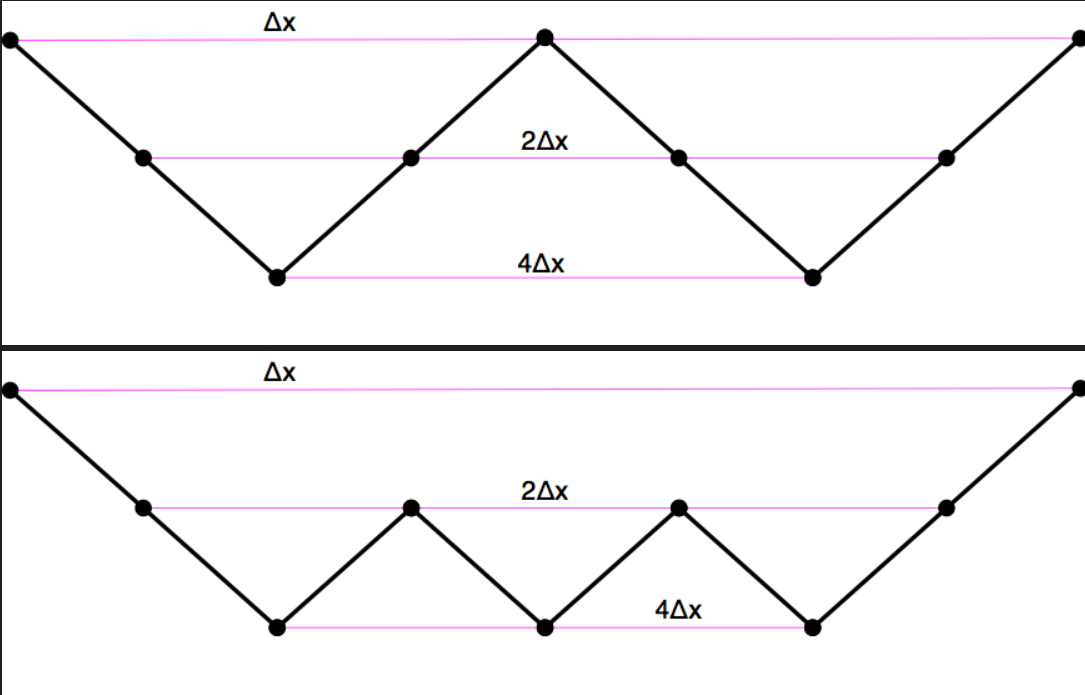

In [ ]:
def smoother(v, N, A, f):
    """Fungsi penghalus menggunakan metode Gauss-Seidel"""
    for i in range(N):
        for k in range(A.shape[0]):
            # Pembaruan nilai v[k] berdasarkan nilai tetangganya
            v[k] = (f[k] - numpy.dot(A[k, 0:k], v[0:k]) - numpy.dot(A[k, k+1:], v[k+1:])) / A[k, k]
    return v

def get_mat(A):
    """Membangun matriks interpolasi (Prolongation) P"""
    f = A.shape[0] # Ukuran grid halus
    c = int((f - 1) / 2 + 1) # Ukuran grid kasar
    P = numpy.zeros((f, c))
    
    # Injeksi titik-titik langsung
    for k in range(c):
        P[2 * k, k] = 1.0
        
    # Interpolasi linier untuk titik-titik di antaranya
    for k in range(c - 1):
        P[2 * k + 1, k] = 0.5
        P[2 * k + 1, k + 1] = 0.5
    return P  

def vcycle(A, f):
    """Algoritma V-cycle Multigrid secara rekursif"""
    # Kasus dasar: jika matriks cukup kecil, selesaikan secara langsung
    if A.shape[0] < 15:
        v = numpy.linalg.solve(A, f)
        return v  
    
    N = 5 # Jumlah iterasi penghalusan
    v = numpy.zeros(A.shape[0])
    
    # 1. Pra-penghalusan (Pre-smoothing)
    v = smoother(v, N, A, f)
    
    # 2. Batasi residu ke grid yang lebih kasar
    P = get_mat(A)
    residu = f - numpy.dot(A, v)
    residu_kasar = numpy.dot(P.T, residu) # Restriksi
    
    # 3. Proyeksikan matriks A ke grid kasar (A_kasar = P^T * A * P)
    A_kasar = numpy.dot(P.T, numpy.dot(A, P))
    
    # 4. Rekursi: Selesaikan masalah galat pada grid yang lebih kasar
    galat_rekursif = vcycle(A_kasar, residu_kasar)
    
    # 5. Koreksi: Interpolasi galat kembali ke grid halus dan tambahkan ke v
    v = numpy.dot(P, galat_rekursif) # Prolongasi
    
    # 6. Pasca-penghalusan (Post-smoothing)
    v = smoother(v, N, A, f)
    
    return v

In [ ]:
# Pengaturan Masalah
a = 0.0
b_batas = 1.0
alpha = 0.0
beta = 3.0
f = lambda x: numpy.exp(x)
u_sebenarnya = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)

# Diskritisasi
m = 50
x_bc = numpy.linspace(a, b_batas, m + 2)
x = x_bc[1:-1]
delta_x = (b_batas - a) / (m + 1)

# Membangun matriks A
A = numpy.zeros((m, m))
diagonal = numpy.ones(m) / delta_x**2
A += numpy.diag(diagonal * 2.0, 0)
A += numpy.diag(-diagonal[:-1], 1)
A += numpy.diag(-diagonal[:-1], -1)

# Membangun sisi ruas kanan (b)
b_vec = -f(x)
b_vec[0] += alpha / delta_x**2
b_vec[-1] += beta / delta_x**2

# Solusi eksak sistem
U_eksak = numpy.linalg.solve(A, b_vec)

# Parameter algoritma
MAX_CYCLES = 50
toleransi = delta_x**2

# Menjalankan Multigrid
U = numpy.zeros(m)
konvergensi_MG = numpy.zeros(MAX_CYCLES)
ukuran_langkah_MG = numpy.zeros(MAX_CYCLES)
norma_residu = numpy.zeros(MAX_CYCLES)
konvergensi_sistem = numpy.zeros(MAX_CYCLES)
berhasil = False

for k in range(MAX_CYCLES):
    U_lama = U.copy()
    
    # Hitung residu
    r = b_vec - numpy.dot(A, U)
    if numpy.linalg.norm(r, ord=2) < toleransi:
        berhasil = True
        break       
    
    # Perbarui solusi menggunakan V-cycle
    U += vcycle(A, r)
    
    # Pengukuran konvergensi
    konvergensi_MG[k] = numpy.linalg.norm(u_sebenarnya(x) - U, ord=2)
    norma_residu[k] = numpy.linalg.norm(r, ord=2)
    ukuran_langkah_MG[k] = numpy.linalg.norm(U - U_lama, ord=2)
    konvergensi_sistem[k] = numpy.linalg.norm(U_eksak - U, ord=2)

if not berhasil:
    print("Iterasi gagal konvergen!")
    print(norma_residu[-10:])
else:
    # Plot hasil akhir
    fig = plt.figure()
    axes = fig.add_subplot(1, 1, 1)
    axes.plot(x, U, 'o', label="Dihitung")
    axes.plot(x_bc, u_sebenarnya(x_bc), 'k', label="Sebenarnya")
    axes.set_title("Solusi untuk $u_{xx} = e^x$")
    axes.set_xlabel("x")
    axes.set_ylabel("u(x)")

    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2.1)
    fig.set_figheight(fig.get_figheight() * 2.2)
    
    # Plot Ukuran Langkah
    axes = fig.add_subplot(2, 2, 1)
    axes.semilogy(numpy.arange(1, k + 1), ukuran_langkah_MG[:k], 'o')
    axes.semilogy(numpy.arange(1, k + 1), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Ukuran Langkah")
    axes.set_xlabel("Iterasi")
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")
    
    # Plot Konvergensi ke Solusi Kontinu
    axes = fig.add_subplot(2, 2, 2)
    axes.semilogy(numpy.arange(1, k + 1), konvergensi_MG[:k], 'o')
    axes.semilogy(numpy.arange(1, k + 1), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Konvergensi ke Solusi Sebenarnya")
    axes.set_xlabel("Iterasi")
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")

    # Plot Norma Residu
    axes = fig.add_subplot(2, 2, 3)
    axes.semilogy(numpy.arange(1, k + 1), norma_residu[:k], 'o')
    axes.semilogy(numpy.arange(1, k + 1), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Residu")
    axes.set_xlabel("Iterasi")
    axes.set_ylabel("$||r||_2$")

    # Plot Konvergensi ke Solusi Sistem Diskrit
    axes = fig.add_subplot(2, 2, 4)
    axes.semilogy(numpy.arange(1, k + 1), konvergensi_sistem[:k], 'o')
    axes.semilogy(numpy.arange(1, k + 1), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Residu Sebenarnya (Sistem)")
    axes.set_xlabel("Iterasi")
    axes.set_ylabel("$||U^* - U||_2$")
    
    print("Angka kondisi matriks = %s" % (numpy.sqrt(numpy.linalg.norm(A) * numpy.linalg.norm(numpy.linalg.inv(A)))))
    
    plt.show()

In [ ]:
# Pengaturan masalah yang sedikit lebih sulit
L = 1.0
m = 512
x_bc = numpy.linspace(0, L, m + 2)
x = x_bc[1:-1]
delta_x = (b_batas - a) / (m + 1) # b_batas dan a dari konteks sebelumnya

# Membangun matriks A (menggunakan normalisasi L^2)
A = numpy.diag(2.0 * numpy.ones(m)) - numpy.diag(numpy.ones(m - 1), 1) / L**2

# Membangun sisi ruas kanan (b) dengan fungsi tan yang bervariasi
b_vec = numpy.tan(numpy.arange(m) / (2 * numpy.pi) * 10)

# Solusi eksak untuk perbandingan
U_eksak = numpy.linalg.solve(A, b_vec)
# Tebakan awal acak
U = numpy.random.random(m)

MAX_CYCLES = 50
toleransi = 1e-10

for k in range(MAX_CYCLES):
    # Hitung residu saat ini
    r = b_vec - numpy.dot(A, U)
    
    # Visualisasi proses konvergensi
    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2)
    
    # Plot Solusi
    axes = fig.add_subplot(1, 2, 1)
    axes.plot(U)
    axes.set_title("Solusi pada iterasi %s" % k)
    
    # Plot Residu
    axes = fig.add_subplot(1, 2, 2)
    axes.plot(r)
    axes.set_title("Residu pada iterasi %s" % k)
    
    # Cek kriteria penghentian
    if numpy.linalg.norm(r) < toleransi:
        print("Konvergen pada iterasi ke-%s" % k)
        break       

    # Perbarui solusi menggunakan V-cycle multigrid
    U += vcycle(A, r)

### Estimasi Kerja

Jadi, seberapa jauh lebih baik metode *multigrid*?
Sebagai contoh konkret, pertimbangkan kembali contoh sebelumnya di mana $m = 2^8 - 1 = 255$ dan menggunakan $n = 3$. Jika kita mengizinkan pengasaran rekursif hingga ke kisi berisi 3 titik (7 level kisi). Pada setiap level, kita menerapkan 3 iterasi Jacobi. Jika kita menerapkan iterasi Jacobi ini saat "turun" dalam *V-cycle* dan saat "naik" (secara teori tidak wajib), kita akan melakukan 6 iterasi Jacobi per level. Ini menghasilkan total 42 iterasi Jacobi pada berbagai kisi yang telah dikasarkan. Total jumlah nilai yang diperbarui kemudian menjadi:
$$
    6 \sum^8_{j=2} 2^j \approx 3072.
$$
Ini kira-kira setara dengan jumlah kerja yang dibutuhkan oleh 12 iterasi pada kisi halus asli. Perbedaan besarnya di sini adalah, karena proses penyapuan (*sweeping*) tersebut, kita sebenarnya telah meredam frekuensi galat dalam rentang yang jauh lebih besar daripada yang bisa dicapai hanya dengan iterasi Jacobi biasa.



Sekarang pertimbangkan kasus yang lebih umum dengan $m + 1 = 2^J$ titik, melakukan rekursi hingga ke satu titik (kira-kira) dan mengambil $n$ iterasi Jacobi pada setiap level. Total kerjanya adalah:
$$
    2 n \sum^J_{j=2}2^j \approx 4 n 2^J \approx 4 n m = \mathcal{O}(m)
$$
dengan asumsi $n \ll m$. Kerja yang dibutuhkan untuk satu *V-cycle*, mengingat jumlah kisi bertumbuh secara $\log_2 m$, tetaplah $\mathcal{O}(m)$. Untuk masalah Poisson, sebenarnya dapat ditunjukkan bahwa jumlah *V-cycle* yang diperlukan dalam pendekatan sederhana kita adalah $\mathcal{O}(m \log m)$ untuk mencapai tingkat galat tertentu yang ditentukan oleh $\Delta x$ asli.

Kita tentu saja dapat bereksperimen dengan berbagai jenis *V-cycle* dan jumlah iterasi, dan variasi ini menghasilkan banyak sekali pendekatan yang berbeda.

### *Full Multigrid* (FMG)

Alih-alih memulai dan menyelesaikan PDE asli pada level yang paling halus, kita juga bisa memulai dari level yang paling kasar. Untuk melakukan ini, kita melakukan beberapa iterasi pada level termudah tersebut atau menyelesaikan masalahnya secara langsung karena biayanya pasti rendah pada level paling kasar. Kita kemudian melakukan interpolasi ke level yang lebih halus berikutnya dan menyelesaikan masalah di sana.



Kita kemudian dapat siklus kembali ke level paling kasar atau terus naik hingga mencapai level paling halus yang kita inginkan sejak awal. Setelah itu, kita beralih kembali ke penyelesaian untuk galat (bukan masalah aslinya) dan melanjutkan proses seperti sebelumnya. Pendekatan ini biasanya disebut sebagai ***full multigrid*** (FMG).

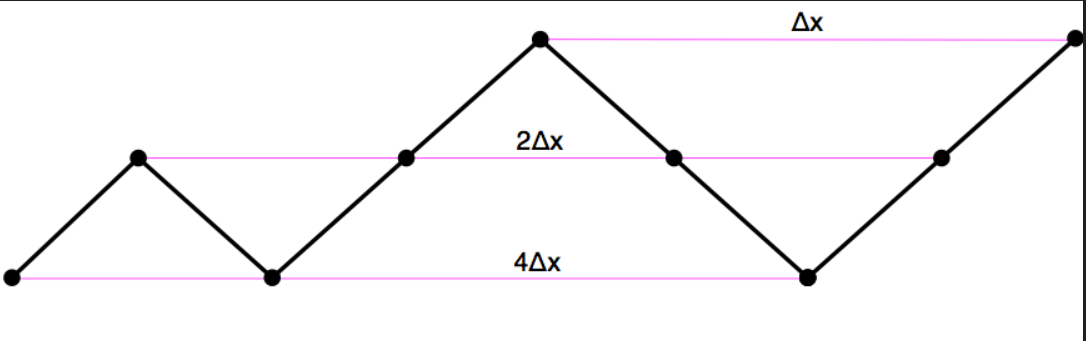

Ternyata, meskipun terdapat fase "persiapan" (*startup*), hal ini sebagian besar dapat diabaikan dan sangat mengurangi galat pada saat kita mencapai level yang paling halus. Penggunaan FMG terbukti membutuhkan kerja sekitar $\mathcal{O}(m)$, yang merupakan nilai optimal mengingat kita memiliki $m$ variabel yang tidak diketahui untuk diselesaikan dalam masalah 1 dimensi.

### Kesimpulan Utama
Kita telah mendiskusikan implementasi multigrid satu dimensi, namun metode-metode ini dapat diperluas ke masalah berdimensi lebih tinggi dan tetap bersifat optimal. Sebagai contoh, masalah Poisson dua dimensi dapat diselesaikan dengan kerja $\mathcal{O}(m^2)$, yang sekali lagi optimal karena jumlah variabel yang tidak diketahui. Pendekatan transformasi Fourier akan membutuhkan $\mathcal{O}(m^2 \log m)$ dan metode langsung membutuhkan $\mathcal{O}(m^3)$.

Meskipun demikian, multigrid adalah hal yang sulit. Ada banyak cara untuk melakukannya sebanyak jumlah masalah yang harus diselesaikan (setidaknya). Beruntungnya, terdapat sejumlah bidang di mana penelitian telah dilakukan untuk menentukan metode yang optimal (dalam beberapa hal) untuk masalah dan diskritisasi tertentu. Ada juga variasi yang mencakup cara-cara yang lebih kompleks untuk "mengasarkan" (*coarsen*) galat dan residu. Secara umum, ini disebut sebagai metode ***algebraic multigrid*** (AMG). Metode ini sangat berguna ketika tidak jelas bagaimana cara melakukan pengasaran pada masalah residu.



### Bacaan Lanjutan
1. W. L. Briggs, V. Emden Henson, and S. F. McCormick. *A Multigrid Tutorial, 2nd ed.* SIAM, Philadelphia, 2000.
2. D. C. Jesperson. Multigrid methods for partial differential equations. In *Studies in Numerical Analysis*, G.H. Golub, ed. MAA Studies in Mathematics, Vol. 24, 1984, halaman 270-317.
3. W. Hackbusch. *Multigrid Methods and Applications.* Springer-Verlag, Berlin, 1985.
4. P. Wesseling. *An Introduction to Multigrid Methods*. John Wiley, New York, 1992.